# FinBERT ESG Scoring & Feature Importance Analysis

This notebook implements:
- **Part 2**: FinBERT-based ESG score generation from 10-K filings
- **Part 3**: Feature importance analysis using existing ESG labels

Based on the implementation guide in `context.md`.

# **Step 1 - Configuration and Imports**

In [1]:
{"success": ["DIS", "GM", "GWW", "MHK", "LYV", "LVS", "CLX", "AACG", "AAL", "AAME", "AAOI", "AAON", "AAPL", "AATC", "AAWW", "AADI", "ABEO", "ABNB", "ABIO", "ABMD", "ABOS", "ABSI", "ABTX", "ABUS", "ABVC", "ACAD", "ACCD", "ACET", "ABCL", "ABCB", "ACHL", "ACHC", "ACIW", "ACLS", "ACIU", "ACHV", "ACMR", "ACOR", "ACNB", "ACRS", "ACRX", "ACT", "ACTG", "ACVA", "ADAG", "ACXP", "ADBE", "ADAP", "ADMA", "ADES", "ADI", "ADIL", "ADMP", "ACER", "ADUS", "ACGL", "ADPT", "ADSK", "ADP", "ADTX", "ADV", "ADVM", "AEHR", "AEHL", "AEI", "AEIS", "AEP", "AEMD", "AESE", "AEYE", "AERI", "AEY", "AFMD", "AFCG", "AFBI", "AFRM", "AFIB", "AGEN", "AFYA", "AGFS", "AGFY", "AGIL", "AGMH", "AGIO", "AGLE", "AGNC", "AGRI", "AGRX", "AGYS", "AGTC", "AHCO", "AHPI", "ADTN", "ADN", "AIKI", "AIP", "AKRO", "AIRT", "AIMC", "AKBA", "AIRG", "AIRS", "AKAM", "AKU", "AKUS", "AKTS", "AKTX", "ALBO", "AKYA", "ALCO", "ALDX", "ALEC", "ALGM", "ALF", "ALGN", "ALGS", "ALKS", "ALIM", "ALGT", "AIH", "ALKT", "ALNY", "ALLT", "ALLO", "AMAT", "AMD", "ATVI", "AVGO", "ANSS", "AMZN", "AIHS", "APA", "BIIB", "BKNG", "CDNS", "CDW", "CHRW", "CINF", "CHTR", "CMCSA", "CPRT", "COST", "CSX", "CTSH", "CME", "CSCO", "CTAS", "CTXS", "CZR", "DISH", "DLTR", "DXCM", "EA", "LNT", "FANG", "EBAY", "LKQ", "GOOGL", "MAR", "MCHP", "LRCX", "MDLZ", "META", "MKTX", "MNST", "MRNA", "MTCH", "MPWR", "MSFT", "MU", "NDAQ", "NLOK", "NTRS", "NWL", "NVDA", "ALLK", "NWSA", "ODFL", "PCAR", "NXPI", "ORLY", "PAYX", "PFG", "ROST", "SBAC", "QCOM", "POOL", "PEP", "SBUX", "REG", "QRVO", "PTC", "PENN", "PYPL", "REGN", "AMGN", "SNPS", "STX", "TECH", "TER", "SWKS", "TRMB", "TROW", "TTWO", "TSLA", "TSCO", "TXN", "TMUS", "UAL", "VRSK", "ULTA", "VRTX", "VTRS", "VRSN", "WBA", "NTAP", "XEL", "XRAY", "ZBRA", "AAP", "ZION", "WYNN", "A", "ABBV", "ABC", "ADM", "ABT", "AEE", "AES", "AFL", "ACN", "AJG", "AIZ", "ALK", "ALB", "AIG", "ALL", "ALLE", "AMP", "AME", "AMT", "AOS", "APD", "AON", "ANET", "APH", "ATO", "AWK", "ARE", "APTV", "AVB", "AVY", "BA", "BAC", "BAX", "BBWI", "BDX", "BIO", "BBY", "BK", "AXP", "BR", "BMY", "BRO", "AZO", "BSX", "BX", "BXP", "SIVB", "C", "CAT", "CARR", "CBRE", "CCI", "CDAY", "CMA", "DHI", "DOV", "DRI", "CE", "DG", "CMG", "DGX", "CCL", "CHD", "DOW", "DFS", "DUK", "DRE", "CF", "DVN", "ECL", "HD", "DTE", "EIX", "GLW", "DVA", "WDC", "GS", "DXC", "ETN", "ED", "HSY", "JNJ", "JPM", "KO", "KMX", "LDOS", "LEG", "MCD", "LIN", "LUMN", "LYB", "MCO", "MCK", "MAS", "LOW", "MDT", "MKC", "MET", "MGM", "MMC", "MO", "BWA", "MRK", "MRO", "MPC", "MS", "MTB", "MTD", "MSI", "NEE", "MSCI", "NCLH", "NI", "NOC", "NOW", "NUE", "NLSN", "NSC", "NVR", "PGR", "PFE", "PHM", "PH", "PKI", "PLD", "PPG", "PSA", "PNC", "PM", "PKG", "PSX", "PRU", "PNR", "PNW", "PPL", "PWR", "RJF", "RF", "RCL", "RL", "PVH", "RHI", "PXD", "ROL", "RMD", "SCHW", "ROK", "TDG", "SEE", "ROP", "SWK", "STZ", "SYK", "SYY", "SHW", "SPGI", "STE", "SYF", "SPG", "SRE", "SO", "STT", "SNA", "RTX", "HIG", "TEL", "TFX", "TFC", "TDY", "TGT", "TJX", "TPR", "TRV", "TMO", "TT", "TSN", "TYL", "TXT", "UNH", "UPS", "UDR", "UHS", "MOS", "USB", "URI", "VNO", "VLO", "VFC", "V", "VTR", "VMC", "WEC", "WELL", "WAT", "WM", "WAB", "WMB", "WFC", "WHR", "WST", "WRB", "WMT", "WU", "YUM", "XYL", "WY", "WRK", "XOM", "ZBH", "ZTS", "DE", "DD", "D", "CVS", "DAL", "CRM", "CVX", "CTVA", "CTRA", "CTLT", "CPB", "CRL", "COP", "COO", "COF", "CNC", "CNP", "CMS", "CMI", "CL", "MMM", "CFG", "CAG", "CI", "CAH", "MA", "LW", "MAA", "MLM", "LUV", "LNC", "LEN", "PG", "OGN", "OXY", "DELL", "PAYC", "PEG", "OKE", "NRG", "L", "OMC", "ORCL", "O", "DPZ", "T", "UNP", "NEM", "FDX", "NKE", "F", "LMT", "RSG", "ENPH", "EXC", "EXPD", "EXPE", "FAST", "FFIV", "FISV", "EQIX", "FTNT", "ETSY", "BEN", "DLR", "DHR", "EFX", "EL", "EMN", "EMR", "EOG", "EQR", "ES", "ESS", "FITB", "ETR", "EXR", "EW", "FOXA", "FCX", "FE", "FLT", "FIS", "FRC", "FMC", "FRT", "FTV", "GPS", "GRMN", "IT", "LLY", "RE", "EVRG", "FBHS", "GILD", "HOLX", "HSIC", "HON", "HST", "GD", "HAS", "HBAN", "GL", "GPC", "GNRC", "GPN", "HCA", "HBI", "HII", "HPE", "HES", "HLT", "HRL", "HPQ", "HUM", "HWM", "PEAK", "GIS", "GE", "SPOT", "TRTN", "TRTX", "TRU", "YETI", "YELP", "YEXT", "SPR", "YSG", "YRD", "YUMC", "TROX", "ZEPP", "ZEV", "ZUO", "ZIM", "ZYME", "ZWS", "YOU", "ZEN", "PLXS", "SHIP", "SHLS", "SHOO", "SHYF", "SIBN", "SIEB", "PLYA", "WWE", "PMCB", "WWW", "XHR", "X", "XPEV", "XPO", "XIN", "XL", "XYF", "Y", "YALA", "WTS", "SIEN", "HAIN", "MTC", "MTCR", "MTEM", "MTLS", "MTEX", "MTRX", "HALO", "HALL", "MVBF", "MVST", "MVIS", "MXCT", "MYGN", "MYFW", "MXL", "MYMD", "MYPS", "MTTR", "MTSI", "CLRO", "CLSN", "GURE", "GVP", "GYRO", "GWRS", "HA", "CLSK", "CLSD", "HAFC", "CLST", "CLWT", "CLXT", "CMBM", "CMCO", "EVK", "CLVS", "CLVR", "HAPP", "HBCP", "HBIO", "HBNC", "HBT", "HCAT", "HARP", "HAYN", "PNBK", "HCDI", "HCCI", "PNFP", "PNT", "POAI", "POLA", "PODD", "POWI", "POWW", "PNRG", "PNTG", "PPBI", "PPIH", "PPC", "PRAA", "PPSI", "PRAX", "PRCT", "PRCH", "PRDO", "SISI", "SITM", "SIRI", "SJ", "POWL", "UPWK", "USAK", "USAU", "USAP", "USEG", "USIO", "UTHR", "URGN", "URBN", "UTME", "UTRS", "UTSI", "UXIN", "UVSP", "CMCM", "CMC", "USLM", "UTMD", "CMP", "CNF", "CNMD", "CNK", "CNNE", "CNO", "CNA", "CMRE", "GVA", "FN", "H", "HASI", "HAYW", "HBB", "HCC", "HCI", "HE", "GWRE", "HAE", "HEP", "HGV", "HI", "HHC", "HUBS", "HESM", "HEI"], "failed": []}


{'success': ['DIS',
  'GM',
  'GWW',
  'MHK',
  'LYV',
  'LVS',
  'CLX',
  'AACG',
  'AAL',
  'AAME',
  'AAOI',
  'AAON',
  'AAPL',
  'AATC',
  'AAWW',
  'AADI',
  'ABEO',
  'ABNB',
  'ABIO',
  'ABMD',
  'ABOS',
  'ABSI',
  'ABTX',
  'ABUS',
  'ABVC',
  'ACAD',
  'ACCD',
  'ACET',
  'ABCL',
  'ABCB',
  'ACHL',
  'ACHC',
  'ACIW',
  'ACLS',
  'ACIU',
  'ACHV',
  'ACMR',
  'ACOR',
  'ACNB',
  'ACRS',
  'ACRX',
  'ACT',
  'ACTG',
  'ACVA',
  'ADAG',
  'ACXP',
  'ADBE',
  'ADAP',
  'ADMA',
  'ADES',
  'ADI',
  'ADIL',
  'ADMP',
  'ACER',
  'ADUS',
  'ACGL',
  'ADPT',
  'ADSK',
  'ADP',
  'ADTX',
  'ADV',
  'ADVM',
  'AEHR',
  'AEHL',
  'AEI',
  'AEIS',
  'AEP',
  'AEMD',
  'AESE',
  'AEYE',
  'AERI',
  'AEY',
  'AFMD',
  'AFCG',
  'AFBI',
  'AFRM',
  'AFIB',
  'AGEN',
  'AFYA',
  'AGFS',
  'AGFY',
  'AGIL',
  'AGMH',
  'AGIO',
  'AGLE',
  'AGNC',
  'AGRI',
  'AGRX',
  'AGYS',
  'AGTC',
  'AHCO',
  'AHPI',
  'ADTN',
  'ADN',
  'AIKI',
  'AIP',
  'AKRO',
  'AIRT',
  'AIMC',
  'AKBA',
  'AIRG

In [2]:
# Uncomment to install dependencies
#%pip install transformers torch pandas numpy scikit-learn xgboost shap matplotlib seaborn tqdm

In [3]:
import pandas as pd
import numpy as np
import json
import os
import re
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Configuration
ESG_DATA_PATH = "../data/ESG_data_cleaned.csv"
SECTIONS_DIR = "../data/extracted_sections"
OUTPUT_DIR = "../data/finbert_features"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Configuration loaded.")

Configuration loaded.


In [4]:
# Load ESG dataset
esg_df = pd.read_csv(ESG_DATA_PATH)
esg_df['ticker'] = esg_df['ticker'].str.upper()
esg_df['cik'] = esg_df['cik'].astype(str).str.zfill(10)

print(f"Loaded {len(esg_df)} companies from ESG dataset")
print(f"Columns: {list(esg_df.columns)}")
esg_df.head()

Loaded 709 companies from ESG dataset
Columns: ['ticker', 'name', 'currency', 'exchange', 'industry', 'environment_grade', 'environment_level', 'social_grade', 'social_level', 'governance_grade', 'governance_level', 'environment_score', 'social_score', 'governance_score', 'total_score', 'last_processing_date', 'total_grade', 'total_level', 'cik']


,ticker,name,currency,exchange,industry,environment_grade,environment_level,social_grade,social_level,governance_grade,governance_level,environment_score,social_score,governance_score,total_score,last_processing_date,total_grade,total_level,cik
0,DIS,Walt Disney Co,USD,"NEW YORK STOCK EXCHANGE, INC.",Media,A,High,BB,Medium,BB,Medium,510,316,321,1147,2022-04-19,BBB,High,0001744489
1,GM,General Motors Co,USD,"NEW YORK STOCK EXCHANGE, INC.",Automobiles,A,High,BB,Medium,B,Medium,510,303,255,1068,2022-04-17,BBB,High,0001467858
2,GWW,WW Grainger Inc,USD,"NEW YORK STOCK EXCHANGE, INC.",Trading Companies and Distributors,B,Medium,BB,Medium,B,Medium,255,385,240,880,2022-04-19,BB,Medium,0000277135
3,MHK,Mohawk Industries Inc,USD,"NEW YORK STOCK EXCHANGE, INC.",Consumer products,A,High,B,Medium,BB,Medium,570,298,303,1171,2022-04-18,BBB,High,0000851968
4,LYV,Live Nation Entertainment Inc,USD,"NEW YORK STOCK EXCHANGE, INC.",Media,BBB,High,BB,Medium,B,Medium,492,310,250,1052,2022-04-18,BBB,High,0001335258


In [5]:
# Check available extracted sections
if os.path.exists(SECTIONS_DIR):
    section_files = [f for f in os.listdir(SECTIONS_DIR) if f.endswith('.json')]
    print(f"Found {len(section_files)} extracted section files")
    
    # Sample one file to check structure
    if section_files:
        sample_file = os.path.join(SECTIONS_DIR, section_files[0])
        with open(sample_file) as f:
            sample = json.load(f)
        print(f"\nSample structure ({section_files[0]}):")
        print(f"  Keys: {list(sample.keys())}")
        print(f"  Sections: {list(sample['sections'].keys())}")
else:
    print(f"Sections directory not found: {SECTIONS_DIR}")
    print("Please run 10-K_filings_data_pull.ipynb first to extract sections.")

Found 344 extracted section files

Sample structure (A.json):
  Keys: ['ticker', 'sections']
  Sections: ['business', 'risk_factors', 'mda']


# **Step 2 - ESG Keyword Definitions**

Define keywords for filtering ESG-relevant sentences from 10-K filings.

In [6]:
ESG_KEYWORDS = {
    "E": [
        "carbon", "emissions", "climate", "renewable", "energy",
        "waste", "water", "biodiversity", "pollution", "greenhouse",
        "sustainability", "environmental", "fossil fuel", "net zero",
        "clean energy", "solar", "wind", "recycling", "landfill"
    ],
    "S": [
        "employee", "workforce", "diversity", "inclusion", "safety",
        "human rights", "labor", "community", "health", "training",
        "wages", "discrimination", "supply chain", "gender",
        "benefits", "minority", "equity", "social impact"
    ],
    "G": [
        "board", "governance", "executive", "compensation", "audit",
        "transparency", "shareholder", "ethics", "compliance", "risk management",
        "whistleblower", "anti-corruption", "disclosure", "accountability",
        "independent director", "code of conduct"
    ]
}

# Extended keyword groups for feature engineering
KEYWORD_GROUPS = {
    "carbon_emissions": ["carbon", "co2", "emissions", "greenhouse gas", "ghg"],
    "renewable_energy": ["renewable", "solar", "wind", "clean energy", "net zero"],
    "climate_risk": ["climate risk", "climate change", "physical risk", "transition risk"],
    "waste_water": ["waste", "water usage", "recycling", "landfill"],
    "diversity": ["diversity", "inclusion", "gender", "minority", "equity"],
    "employee_welfare": ["employee", "workforce", "safety", "health", "training", "benefits"],
    "human_rights": ["human rights", "forced labor", "child labor", "modern slavery"],
    "community": ["community", "philanthropy", "charitable", "social impact"],
    "board_governance": ["board of directors", "independent director", "audit committee"],
    "executive_pay": ["executive compensation", "ceo pay", "incentive", "bonus"],
    "ethics_compliance": ["ethics", "compliance", "anti-corruption", "whistleblower", "code of conduct"],
    "transparency": ["disclosure", "transparency", "reporting", "accountability"],
    "regulatory_penalties": ["fine", "penalty", "violation", "lawsuit", "settlement", "litigation"],
    "controversy": ["controversy", "scandal", "misconduct", "fraud", "investigation"]
}

print(f"ESG keywords defined:")
for pillar, keywords in ESG_KEYWORDS.items():
    print(f"  {pillar}: {len(keywords)} keywords")
print(f"\nKeyword groups for features: {len(KEYWORD_GROUPS)} groups")

ESG keywords defined:
  E: 19 keywords
  S: 18 keywords
  G: 16 keywords

Keyword groups for features: 14 groups


# **Step 3 - FinBERT Setup**

Load the FinBERT model for financial sentiment analysis.

In [7]:
from transformers import BertTokenizer, BertForSequenceClassification
import torch

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load FinBERT
print("Loading FinBERT model...")
tokenizer = BertTokenizer.from_pretrained("ProsusAI/finbert")
model = BertForSequenceClassification.from_pretrained("ProsusAI/finbert")
model.to(device)
model.eval()

LABEL_MAP = {0: "positive", 1: "negative", 2: "neutral"}
print("FinBERT loaded successfully.")

Using device: cpu
Loading FinBERT model...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 903.59it/s, Materializing param=classifier.weight]                                       
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FinBERT loaded successfully.


# **Step 4 - Helper Functions**

Functions for text processing, sentence filtering, and FinBERT inference.

In [8]:
def filter_esg_sentences(text, pillar):
    """Filter sentences containing ESG keywords for a specific pillar."""
    if text is None:
        return []
    sentences = re.split(r'(?<=[.!?])\s+', text)
    keywords = ESG_KEYWORDS[pillar]
    filtered = []
    for s in sentences:
        s_lower = s.lower()
        if any(kw in s_lower for kw in keywords):
            # Clean up the sentence
            s_clean = ' '.join(s.split())
            if len(s_clean) > 20 and len(s_clean) < 1000:  # Filter out too short/long
                filtered.append(s_clean)
    return filtered

def chunk_text(text, max_tokens=400, overlap=50):
    """Chunk text for FinBERT's 512 token limit."""
    tokens = tokenizer.tokenize(text)
    chunks = []
    for i in range(0, len(tokens), max_tokens - overlap):
        chunk = tokens[i:i + max_tokens]
        chunks.append(tokenizer.convert_tokens_to_string(chunk))
    return chunks

print("Text helper functions defined.")

Text helper functions defined.


In [9]:
def run_finbert_batch(sentences, batch_size=16):
    """Run FinBERT on a batch of sentences."""
    results = []
    
    for i in range(0, len(sentences), batch_size):
        batch = sentences[i:i + batch_size]
        batch = [s for s in batch if len(s.strip()) > 10]
        
        if not batch:
            continue
            
        inputs = tokenizer(
            batch,
            return_tensors="pt",
            max_length=512,
            truncation=True,
            padding=True
        ).to(device)
        
        with torch.no_grad():
            outputs = model(**inputs)
            probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()
        
        for j, (text, prob) in enumerate(zip(batch, probs)):
            results.append({
                "text": text[:100] + "..." if len(text) > 100 else text,
                "positive": float(prob[0]),
                "negative": float(prob[1]),
                "neutral": float(prob[2]),
                "label": LABEL_MAP[np.argmax(prob)]
            })
    
    return results

print("FinBERT inference function defined.")

FinBERT inference function defined.


In [10]:
def compute_pillar_score(finbert_results, weight_neutral=0.3):
    """Aggregate FinBERT results into a single pillar score (0-100)."""
    if not finbert_results:
        return 0.0
    
    scores = []
    for r in finbert_results:
        # Score formula: positive contributes +1, neutral contributes +weight_neutral, negative contributes -1
        score = (r["positive"] * 1.0) + (r["neutral"] * weight_neutral) + (r["negative"] * -1.0)
        scores.append(score)
    
    raw_score = np.mean(scores)  # Range: approximately -1 to 1
    normalized = (raw_score + 1) / 2 * 100  # Normalize to 0-100
    return round(normalized, 2)

print("Score aggregation function defined.")

Score aggregation function defined.


# **Step 5 - Feature Extraction Functions**

Extract FinBERT sentiment features, keyword frequencies, structural features, and quantitative signals.

In [11]:
def extract_finbert_features(text, max_sentences=100):
    """Extract FinBERT-based sentiment features for each ESG pillar."""
    features = {}
    
    for pillar in ["E", "S", "G"]:
        sentences = filter_esg_sentences(text, pillar)[:max_sentences]
        
        if not sentences:
            for suffix in ["pos_mean", "neg_mean", "neu_mean", "pos_std", "neg_std", 
                          "sentence_count", "pos_neg_ratio", "pillar_score"]:
                features[f"{pillar}_{suffix}"] = 0.0
            continue
        
        results = run_finbert_batch(sentences)
        
        if not results:
            for suffix in ["pos_mean", "neg_mean", "neu_mean", "pos_std", "neg_std", 
                          "sentence_count", "pos_neg_ratio", "pillar_score"]:
                features[f"{pillar}_{suffix}"] = 0.0
            continue
        
        pos_scores = [r["positive"] for r in results]
        neg_scores = [r["negative"] for r in results]
        neu_scores = [r["neutral"] for r in results]
        
        features[f"{pillar}_pos_mean"] = np.mean(pos_scores)
        features[f"{pillar}_neg_mean"] = np.mean(neg_scores)
        features[f"{pillar}_neu_mean"] = np.mean(neu_scores)
        features[f"{pillar}_pos_std"] = np.std(pos_scores)
        features[f"{pillar}_neg_std"] = np.std(neg_scores)
        features[f"{pillar}_sentence_count"] = len(results)
        
        n_pos = sum(1 for r in results if r["label"] == "positive")
        n_neg = sum(1 for r in results if r["label"] == "negative")
        features[f"{pillar}_pos_neg_ratio"] = n_pos / (n_neg + 1e-6)
        features[f"{pillar}_pillar_score"] = compute_pillar_score(results)
    
    return features

print("FinBERT feature extraction function defined.")

FinBERT feature extraction function defined.


In [12]:
def extract_keyword_features(text):
    """Extract keyword frequency features."""
    if text is None:
        return {f"kw_{group}_freq": 0.0 for group in KEYWORD_GROUPS}
    
    text_lower = text.lower()
    word_count = len(text_lower.split())
    
    if word_count == 0:
        return {f"kw_{group}_freq": 0.0 for group in KEYWORD_GROUPS}
    
    features = {}
    for group_name, keywords in KEYWORD_GROUPS.items():
        count = sum(text_lower.count(kw) for kw in keywords)
        features[f"kw_{group_name}_freq"] = count / word_count * 1000  # Per 1000 words
        features[f"kw_{group_name}_present"] = int(count > 0)
    
    return features

print("Keyword feature extraction function defined.")

Keyword feature extraction function defined.


In [13]:
def extract_structural_features(sections):
    """Extract structural features from filing sections."""
    features = {}
    
    # Combine all sections
    combined_text = " ".join([s for s in sections.values() if s])
    total_length = len(combined_text.split()) if combined_text else 0
    
    features["doc_length"] = total_length
    features["num_sections"] = sum(1 for s in sections.values() if s)
    
    # Section-specific lengths
    for section_name in ["business", "risk_factors", "mda"]:
        section_text = sections.get(section_name, "")
        section_length = len(section_text.split()) if section_text else 0
        features[f"{section_name}_length"] = section_length
        features[f"{section_name}_pct"] = section_length / total_length if total_length > 0 else 0
    
    # ESG coverage per pillar
    for pillar in ["E", "S", "G"]:
        relevant = filter_esg_sentences(combined_text, pillar)
        relevant_length = sum(len(s.split()) for s in relevant)
        features[f"{pillar}_coverage_pct"] = relevant_length / total_length if total_length > 0 else 0
    
    # Check for sustainability-related sections in business description
    business_text = sections.get("business", "") or ""
    features["has_sustainability_mention"] = int(
        "sustainability" in business_text.lower() or 
        "environmental" in business_text.lower()
    )
    
    return features

print("Structural feature extraction function defined.")

Structural feature extraction function defined.


In [14]:
def extract_quantitative_features(text):
    """Extract quantitative signal features using regex patterns."""
    if text is None:
        return {f"has_{name}": 0 for name in ["emissions_numbers", "dollar_fines", 
                                               "employee_numbers", "percent_renewable",
                                               "women_leadership", "board_independence"]}
    
    features = {}
    patterns = {
        "emissions_numbers": r'\d+[\.,]?\d*\s*(?:metric tons?|MT|tCO2|MtCO2)',
        "dollar_fines": r'\$[\d,]+\s*(?:million|billion)?\s*(?:fine|penalty|settlement)',
        "employee_numbers": r'(\d+[\.,]?\d*)\s*(?:full[- ]time\s+)?employees',
        "percent_renewable": r'(\d+)\s*%\s*(?:renewable|clean|green)\s*energy',
        "women_leadership": r'(\d+)\s*%\s*(?:women|female)\s*(?:in\s+)?(?:leadership|management|board)',
        "board_independence": r'(\d+)\s*(?:of\s+)?(?:\d+\s+)?(?:independent|outside)\s+directors?'
    }
    
    for feat_name, pattern in patterns.items():
        matches = re.findall(pattern, text, re.IGNORECASE)
        features[f"has_{feat_name}"] = int(len(matches) > 0)
        features[f"count_{feat_name}"] = len(matches)
    
    return features

print("Quantitative feature extraction function defined.")

Quantitative feature extraction function defined.


# **Step 6 - Build Feature Matrix**

Process all companies to extract features and build the training dataset.

In [15]:
def load_sections(ticker, sections_dir=SECTIONS_DIR):
    """Load extracted sections for a ticker."""
    filepath = os.path.join(sections_dir, f"{ticker}.json")
    if not os.path.exists(filepath):
        return None
    with open(filepath) as f:
        data = json.load(f)
    return data.get("sections", {})

def process_company(ticker, sections_dir=SECTIONS_DIR):
    """Extract all features for a single company."""
    sections = load_sections(ticker, sections_dir)
    if sections is None:
        return None
    
    # Combine all sections for text analysis
    combined_text = " ".join([s for s in sections.values() if s])
    if not combined_text or len(combined_text) < 100:
        return None
    
    features = {"ticker": ticker}
    
    # Extract all feature types
    features.update(extract_finbert_features(combined_text))
    features.update(extract_keyword_features(combined_text))
    features.update(extract_structural_features(sections))
    features.update(extract_quantitative_features(combined_text))
    
    return features

print("Company processing functions defined.")

Company processing functions defined.


In [16]:
# Check which companies have extracted sections and analyze sizes
available_tickers = []
section_sizes = []

if os.path.exists(SECTIONS_DIR):
    section_files = [f for f in os.listdir(SECTIONS_DIR) if f.endswith('.json')]
    
    for fname in section_files:
        ticker = fname.replace('.json', '').upper()
        filepath = os.path.join(SECTIONS_DIR, fname)
        
        with open(filepath) as f:
            data = json.load(f)
        
        sections = data.get('sections', {})
        business_len = len(sections.get('business', '') or '')
        risk_len = len(sections.get('risk_factors', '') or '')
        mda_len = len(sections.get('mda', '') or '')
        total_len = business_len + risk_len + mda_len
        
        section_sizes.append({
            'ticker': ticker,
            'business_chars': business_len,
            'risk_chars': risk_len,
            'mda_chars': mda_len,
            'total_chars': total_len
        })
    
    size_df = pd.DataFrame(section_sizes)
    print(f"Found {len(size_df)} companies with extracted sections")
    print(f"\nSection size summary (characters):")
    print(size_df[['business_chars', 'risk_chars', 'mda_chars', 'total_chars']].describe())
else:
    print("No extracted sections found. Please run 10-K_filings_data_pull.ipynb first.")
    size_df = pd.DataFrame()

Found 344 companies with extracted sections

Section size summary (characters):
       business_chars     risk_chars      mda_chars   total_chars
count      344.000000     344.000000     344.000000  3.440000e+02
mean     65810.877907  121711.302326   95745.709302  2.832679e+05
std      82852.575978  110729.481284   90153.831154  1.884396e+05
min          0.000000       0.000000       0.000000  7.580000e+03
25%      26200.750000   56665.250000   44981.000000  1.599902e+05
50%      46885.500000   84485.000000   63987.500000  2.217170e+05
75%      69752.750000  149908.250000  109497.000000  3.721205e+05
max     500000.000000  500000.000000  500000.000000  1.229326e+06


### Filter Outliers

Some companies have section sizes in the millions of characters (extraction errors). Filter these out before FinBERT processing.

In [17]:
# Filter out companies with incomplete sections (any 0s)
# We only want companies with all 3 sections extracted

if len(size_df) > 0:
    # Keep only companies with all 3 sections (no zeros)
    complete_mask = (
        (size_df['business_chars'] > 0) &
        (size_df['risk_chars'] > 0) &
        (size_df['mda_chars'] > 0)
    )
    
    complete_df = size_df[complete_mask]
    incomplete_df = size_df[~complete_mask]
    
    print(f"--- Filtering Results ---")
    print(f"Total companies: {len(size_df)}")
    print(f"Complete (3/3 sections): {len(complete_df)}")
    print(f"Incomplete (missing sections): {len(incomplete_df)}")
    
    if len(incomplete_df) > 0:
        print(f"\nRemoved companies with missing sections:")
        print(incomplete_df[['ticker', 'business_chars', 'risk_chars', 'mda_chars']].to_string(index=False))
    
    # Update available_tickers to only include complete companies
    available_tickers = complete_df['ticker'].tolist()
    print(f"\nProceeding with {len(available_tickers)} complete companies for feature extraction")

--- Filtering Results ---
Total companies: 344
Complete (3/3 sections): 332
Incomplete (missing sections): 12

Removed companies with missing sections:
ticker  business_chars  risk_chars  mda_chars
  AEMD               0      123473      36542
   AEY           19935           0      25398
   APA               0       72290      92658
   CLX          108680           0        583
   DTE               0       35090      63647
   EIX               0           0     500000
  FANG               0      181188      36485
   LYB               0       67023     131689
  NTRS               0           0     482428
   PHM               0       43088      56088
   PPL            8294       37537          0
   PSX               0      500000     116501

Proceeding with 332 complete companies for feature extraction


In [18]:
# Process all companies (this may take a while with FinBERT)
# Extraction is enabled - will process all available companies
RUN_FULL_EXTRACTION = True  # Set to False to skip extraction

if RUN_FULL_EXTRACTION and available_tickers:
    all_features = []
    failed = []
    
    for ticker in tqdm(available_tickers, desc="Extracting features"):
        try:
            features = process_company(ticker)
            if features:
                all_features.append(features)
            else:
                failed.append(ticker)
        except Exception as e:
            print(f"Error processing {ticker}: {e}")
            failed.append(ticker)
    
    print(f"\nProcessed {len(all_features)} companies successfully")
    print(f"Failed: {len(failed)} companies")
    
    # Create feature DataFrame
    feature_df = pd.DataFrame(all_features)
    
    # Save features
    feature_df.to_csv(os.path.join(OUTPUT_DIR, "finbert_features.csv"), index=False)
    print(f"\nFeatures saved to {OUTPUT_DIR}/finbert_features.csv")
else:
    print("Feature extraction not run. Set RUN_FULL_EXTRACTION = True to extract features.")
    print("Note: This requires extracted sections from 10-K_filings_data_pull.ipynb")

Extracting features:   3%|▎         | 10/332 [03:53<2:05:19, 23.35s/it]


KeyboardInterrupt: 

In [19]:
# Test on a single company
TEST_TICKER = "MSFT"  # Change to test different companies

if TEST_TICKER.upper() in [t.upper() for t in available_tickers]:
    print(f"Testing feature extraction on {TEST_TICKER}...")
    test_features = process_company(TEST_TICKER.upper())
    
    if test_features:
        print(f"\nExtracted {len(test_features)} features:")
        for key, value in test_features.items():
            if isinstance(value, float):
                print(f"  {key}: {value:.4f}")
            else:
                print(f"  {key}: {value}")
    else:
        print(f"Could not extract features for {TEST_TICKER}")
else:
    print(f"{TEST_TICKER} not found in available tickers.")
    if available_tickers:
        print(f"Available tickers (first 10): {available_tickers[:10]}")

Testing feature extraction on MSFT...

Extracted 77 features:
  ticker: MSFT
  E_pos_mean: 0.3345
  E_neg_mean: 0.1139
  E_neu_mean: 0.5515
  E_pos_std: 0.3316
  E_neg_std: 0.2451
  E_sentence_count: 67
  E_pos_neg_ratio: 2.6250
  E_pillar_score: 69.3000
  S_pos_mean: 0.3123
  S_neg_mean: 0.1379
  S_neu_mean: 0.5498
  S_pos_std: 0.3045
  S_neg_std: 0.2757
  S_sentence_count: 100
  S_pos_neg_ratio: 2.2143
  S_pillar_score: 66.9700
  G_pos_mean: 0.1405
  G_neg_mean: 0.1772
  G_neu_mean: 0.6823
  G_pos_std: 0.2234
  G_neg_std: 0.2982
  G_sentence_count: 99
  G_pos_neg_ratio: 0.6875
  G_pillar_score: 58.4000
  kw_carbon_emissions_freq: 0.2040
  kw_carbon_emissions_present: 1
  kw_renewable_energy_freq: 2.6525
  kw_renewable_energy_present: 1
  kw_climate_risk_freq: 0.0340
  kw_climate_risk_present: 1
  kw_waste_water_freq: 0.0340
  kw_waste_water_present: 1
  kw_diversity_freq: 0.9522
  kw_diversity_present: 1
  kw_employee_welfare_freq: 4.7609
  kw_employee_welfare_present: 1
  kw_human_r

# **Step 7 - Merge with ESG Labels**

Combine extracted features with ground truth ESG scores.

In [20]:
# Load features (either from extraction or saved file)
features_path = os.path.join(OUTPUT_DIR, "finbert_features.csv")

if os.path.exists(features_path):
    feature_df = pd.read_csv(features_path)
    feature_df['ticker'] = feature_df['ticker'].str.upper()
    print(f"Loaded {len(feature_df)} companies from saved features")
elif 'feature_df' in dir() and len(feature_df) > 0:
    print(f"Using {len(feature_df)} companies from extraction")
else:
    print("No features available. Run extraction first.")
    feature_df = pd.DataFrame()

Loaded 332 companies from saved features


In [21]:
# Merge with ESG labels
if len(feature_df) > 0:
    merged_df = feature_df.merge(
        esg_df[['ticker', 'industry', 'environment_score', 'social_score', 
                'governance_score', 'total_score', 'total_grade']],
        on='ticker',
        how='inner'
    )
    print(f"Merged dataset: {len(merged_df)} companies")
    print(f"\nTarget variable distributions:")
    print(merged_df[['environment_score', 'social_score', 'governance_score', 'total_score']].describe())
else:
    print("No features to merge.")
    merged_df = pd.DataFrame()

Merged dataset: 332 companies

Target variable distributions:
       environment_score  social_score  governance_score  total_score
count         332.000000    332.000000        332.000000   332.000000
mean          412.201807    293.340361        282.141566   987.683735
std           142.845145     55.323889         47.740814   216.436016
min           200.000000    160.000000        200.000000   600.000000
25%           250.000000    244.750000        235.000000   774.500000
50%           500.000000    303.000000        300.000000  1068.000000
75%           519.250000    324.000000        310.000000  1145.500000
max           719.000000    570.000000        475.000000  1533.000000


# **Step 7.5 - Feature Engineering**

Apply recommendations from EDA (`EDA_10-K_filings.ipynb`) before modeling:

1. **Drop zero-variance features** â€” `num_sections` (constant), `has_women_leadership`, `count_women_leadership`, `has_board_independence`, `count_board_independence` (all zero), `kw_employee_welfare_present` (100% present)
2. **Drop near-universal presence flags** (>95%) â€” `kw_ethics_compliance_present`, `kw_transparency_present`, `kw_regulatory_penalties_present`, `kw_diversity_present`, `kw_board_governance_present`; frequency features for these topics are kept
3. **Clip `pos_neg_ratio`** at 99th percentile â€” eliminates division artifacts (max was 9,000,000) caused by near-zero negative means
4. **Log-transform keyword frequency features** â€” all `kw_*_freq` columns are right-skewed; replaced with `log(x+1)` versions
5. **Add one-hot industry encoding** â€” industry is the dominant driver of environment score variation and was absent from the original feature set

In [26]:
import numpy as np

# 1. Features to drop outright
# Zero-variance features (no discriminative signal)
ZERO_VAR = [
    'num_sections',               # constant = 3 for all companies
    'kw_employee_welfare_present',# 100% present
    'has_women_leadership',       # 0% present (regex matched nothing)
    'count_women_leadership',     # all zeros
    'has_board_independence',     # 0% present (regex matched nothing)
    'count_board_independence',   # all zeros
]

# Near-universal presence flags (>95% of companies) binary flag carries no signal;
# the frequency feature for the same topic is kept
NEAR_UNIVERSAL_PRESENCE = [
    'kw_ethics_compliance_present',    # 99.7%
    'kw_transparency_present',         # 99.7%
    'kw_regulatory_penalties_present', # 99.7%
    'kw_diversity_present',            # 99.4%
    'kw_board_governance_present',     # 96.7%
]

DROP_COLS = ZERO_VAR + NEAR_UNIVERSAL_PRESENCE

# 2. Clip pos_neg_ratio at 99th percentile
# Division artifacts create values up to 9,000,000 when neg_mean 0
engineered_df = merged_df.copy()
for pillar in ['E', 'S', 'G']:
    col = f'{pillar}_pos_neg_ratio'
    cap = engineered_df[col].quantile(0.99)
    engineered_df[col] = engineered_df[col].clip(upper=cap)

# 3. Log-transform all keyword frequency features
# All kw_*_freq distributions are right-skewed; log(x+1) normalises them
kw_freq_cols = [c for c in engineered_df.columns
                if c.startswith('kw_') and c.endswith('_freq')]
for col in kw_freq_cols:
    engineered_df[f'{col}_log'] = np.log1p(engineered_df[col])

# 4. Drop the raw (un-transformed) freq cols and the flagged cols 
# Keep log-transformed versions; drop raw freq and the flagged cols
DROP_COLS += kw_freq_cols   # replace raw freq with log versions
engineered_df.drop(columns=[c for c in DROP_COLS if c in engineered_df.columns],
                   inplace=True)

# 5. Add one-hot encoded industry
ind_dummies = pd.get_dummies(engineered_df['industry'], prefix='ind')
engineered_df = pd.concat([engineered_df, ind_dummies], axis=1)

# Summary
exclude = ['ticker', 'industry', 'environment_score', 'social_score',
           'governance_score', 'total_score', 'total_grade']
new_feature_cols = [c for c in engineered_df.columns if c not in exclude]

print("Feature Engineering Summary")
print("="*50)
print(f"  Original features:     {len([c for c in merged_df.columns if c not in exclude])}")
print(f"  Dropped (zero/near-universal): {len(DROP_COLS) - len(kw_freq_cols)} cols")
print(f"  Raw kw_freq replaced by log:  {len(kw_freq_cols)} log cols")
print(f"  Industry dummies added:         {ind_dummies.shape[1]} cols")
print(f"  Final feature count:   {len(new_feature_cols)}")
print(f"  Shape: {engineered_df[new_feature_cols].shape}")

Feature Engineering Summary
  Original features:     76
  Dropped (zero/near-universal): 11 cols
  Raw kw_freq replaced by log:  14 log cols
  Industry dummies added:         38 cols
  Final feature count:   103
  Shape: (332, 103)


# **Step 7.6 - Merge SEC EDGAR Structured Features**

Merge FY2021 financial fundamentals from the SEC EDGAR Company Facts API.

**Features added (5, reduced from 9 to limit multicollinearity):**

- `log_total_assets` — primary size proxy (99% coverage; canonical balance-sheet scale measure)
- `log_public_float` — market-cap proxy; captures investor-perceived value, not fully redundant with assets
- `debt_to_assets` — leverage ratio; orthogonal to scale
- `profit_margin` — net income / revenue; profitability, orthogonal to scale
- `return_on_equity` — net income / equity; efficiency, orthogonal to scale

**Dropped to avoid multicollinearity:** `log_total_revenue`, `log_stockholders_equity`,
`log_cash_and_equivalents`, `log_long_term_debt` (all highly correlated with `log_total_assets`;
`log_long_term_debt` also has 51% missingness).

**Imputation strategy:** industry-median first, global-median fallback — size and leverage
vary substantially across industries.

In [27]:
STRUCTURED_FEATURES_PATH = os.path.join(
    os.path.dirname(OUTPUT_DIR), "structured_features", "sec_fundamentals.csv"
)

# Reduced feature set — 5 columns chosen to limit multicollinearity.
# log_total_revenue, log_stockholders_equity, log_cash_and_equivalents, and
# log_long_term_debt are all highly correlated with log_total_assets and are excluded.
STRUCTURED_COLS = [
    "log_total_assets",    # primary size proxy
    "log_public_float",    # market-cap proxy — not fully redundant with assets
    "debt_to_assets",      # leverage ratio
    "profit_margin",       # profitability ratio
    "return_on_equity",    # efficiency ratio
]

if os.path.exists(STRUCTURED_FEATURES_PATH):
    sec_df = pd.read_csv(STRUCTURED_FEATURES_PATH)
    sec_df["ticker"] = sec_df["ticker"].str.upper()

    # Keep only the columns we want to merge
    available_cols = [c for c in STRUCTURED_COLS if c in sec_df.columns]
    missing_cols   = [c for c in STRUCTURED_COLS if c not in sec_df.columns]
    if missing_cols:
        print(f"Warning: expected columns not found in sec_fundamentals.csv: {missing_cols}")
        print("Run structured_features_collection.ipynb first.")

    sec_merge = sec_df[["ticker"] + available_cols].copy()

    # ── Industry-median imputation ────────────────────────────────────────────────
    # Attach industry temporarily for group-level imputation
    sec_merge = sec_merge.merge(
        engineered_df[["ticker", "industry"]].drop_duplicates(),
        on="ticker", how="left"
    )

    for col in available_cols:
        # 1. Fill with industry median
        ind_median = sec_merge.groupby("industry")[col].transform("median")
        sec_merge[col] = sec_merge[col].fillna(ind_median)
        # 2. Fall back to global median for any remaining NaNs
        global_median = sec_merge[col].median()
        sec_merge[col] = sec_merge[col].fillna(global_median)

    sec_merge.drop(columns=["industry"], inplace=True)

    # ── Clip ratio extremes (winsorise at 1st/99th percentile) ───────────────────
    for col in ["profit_margin", "return_on_equity", "debt_to_assets"]:
        if col in sec_merge.columns:
            lo, hi = sec_merge[col].quantile([0.01, 0.99])
            sec_merge[col] = sec_merge[col].clip(lo, hi)

    # ── Merge into engineered_df ──────────────────────────────────────────────────
    pre_cols = len(engineered_df.columns)
    engineered_df = engineered_df.merge(sec_merge, on="ticker", how="left")

    print("SEC Structured Features Merge Summary")
    print("=" * 50)
    print(f"  Companies matched:        {sec_merge['ticker'].isin(engineered_df['ticker']).sum()} / {len(engineered_df)}")
    print(f"  Features added:           {len(engineered_df.columns) - pre_cols}")
    print(f"  Engineered_df shape now:  {engineered_df.shape}")
    print()
    print("Post-imputation missing values:")
    missing = engineered_df[available_cols].isna().sum()
    print(missing[missing > 0].to_string() if missing.any() else "  None — all values imputed.")

else:
    print("[SKIP] sec_fundamentals.csv not found.")
    print("Run work/structured_features_collection.ipynb first, then re-run this cell.")
    print("Modeling will continue without structured features.")

SEC Structured Features Merge Summary
  Companies matched:        332 / 332
  Features added:           5
  Engineered_df shape now:  (332, 115)

Post-imputation missing values:
  None — all values imputed.


# **Step 7.7 - Filter Bad Extractions**

Remove companies with critically corrupted 10-K text identified by the extraction quality audit (`EDA_10-K_filings.ipynb`).

**9 critical companies removed (severity 2):**

- `COST`, `AKTS`, `NTAP` — XBRL markup extracted instead of narrative text; FinBERT sentiment features are meaningless
- `ACNB`, `DXCM`, `EBAY`, `TER`, `AOS` — 2-section cap hits caused extractor to lose position; MD&A is a ~162-char TOC stub
- `LOW` — 2-section cap + 11.6% duplicate sentence rate

**2 borderline companies retained (severity 1):**

- `ARE` — Business section only 3,233 chars (likely missed section start)
- `STX` — Business section hit cap (unusual pattern)

**Requires:** `data/structured_features/extraction_quality.csv` (generated by the audit cell in `EDA_10-K_filings.ipynb`).

In [28]:
EXTRACTION_QUALITY_PATH = os.path.join(
    os.path.dirname(OUTPUT_DIR), "structured_features", "extraction_quality.csv"
)

if os.path.exists(EXTRACTION_QUALITY_PATH):
    eq_df = pd.read_csv(EXTRACTION_QUALITY_PATH)
    eq_df["ticker"] = eq_df["ticker"].str.upper()

    # Merge flag into engineered_df
    engineered_df = engineered_df.merge(
        eq_df[["ticker", "bad_extraction"]], on="ticker", how="left"
    )
    # Companies not in the flag file are assumed clean
    engineered_df["bad_extraction"] = engineered_df["bad_extraction"].fillna(0).astype(int)

    pre_count = len(engineered_df)
    critical = engineered_df[engineered_df["bad_extraction"] == 2]
    
    print("Extraction Quality Filter")
    print("=" * 50)
    print(f"  Companies before filter:  {pre_count}")
    print(f"  Critical (severity 2):    {len(critical)}")
    print(f"  Borderline (severity 1):  {(engineered_df['bad_extraction'] == 1).sum()}  [retained]")
    print(f"  Clean (severity 0):       {(engineered_df['bad_extraction'] == 0).sum()}")
    print()
    
    if len(critical) > 0:
        print("  Removed companies:")
        for _, row in critical.iterrows():
            print(f"    {row['ticker']:<8}")
    
    # Remove critical, keep borderline and clean
    engineered_df = engineered_df[engineered_df["bad_extraction"] < 2].copy()
    engineered_df.drop(columns=["bad_extraction"], inplace=True)
    
    print(f"\n  Companies after filter:   {len(engineered_df)}")
    print(f"  Engineered_df shape now:  {engineered_df.shape}")

else:
    print("[SKIP] extraction_quality.csv not found.")
    print("Run the extraction audit cell in EDA_10-K_filings.ipynb first.")
    print("Modeling will continue with all 332 companies.")

Extraction Quality Filter
  Companies before filter:  332
  Critical (severity 2):    9
  Borderline (severity 1):  2  [retained]
  Clean (severity 0):       321

  Removed companies:
    ACNB    
    AKTS    
    AOS     
    COST    
    DXCM    
    EBAY    
    LOW     
    NTAP    
    TER     

  Companies after filter:   323
  Engineered_df shape now:  (323, 115)


# **Step 7.8 — Disclosure Threshold Analysis**

The bimodal environment score distribution (peaks at ~200 and ~510) is present across all pillars
and persists within individual industries, suggesting it is driven by the **rating algorithm's
treatment of disclosure** rather than genuine differences in company ESG performance.

**Hypothesis:** The rating provider applies a discrete scoring rule — companies that meet a minimum
disclosure threshold receive scores ≥500 on environment, while those that don't are structurally
capped in the ~200–300 range. The 2020 ESG methodology change (assigning 0 for unreported metrics
instead of benefit-of-the-doubt) would amplify this effect.

**Approach:** Fit a shallow decision tree to classify companies as above vs. below 500 on
environment score using the full engineered feature set. The tree splits reveal the feature
thresholds that best separate the two modes — effectively reverse-engineering the rater's
decision rule from observable data.

Disclosure threshold classification (environment_score >= 500)
  Above threshold: 171 companies (52.9%)
  Below threshold: 152 companies (47.1%)
  Features: 103

Shallow tree (depth=3) — 5-fold CV accuracy: 0.606 ± 0.093

Decision Rules (depth=3):
|--- E_coverage_pct <= 0.05
|   |--- ind_Technology <= 0.50
|   |   |--- kw_climate_risk_freq_log <= 0.24
|   |   |   |--- class: 0
|   |   |--- kw_climate_risk_freq_log >  0.24
|   |   |   |--- class: 1
|   |--- ind_Technology >  0.50
|   |   |--- class: 1
|--- E_coverage_pct >  0.05
|   |--- S_coverage_pct <= 0.17
|   |   |--- E_neu_mean <= 0.61
|   |   |   |--- class: 1
|   |   |--- E_neu_mean >  0.61
|   |   |   |--- class: 1
|   |--- S_coverage_pct >  0.17
|   |   |--- S_neg_std <= 0.38
|   |   |   |--- class: 1
|   |   |--- S_neg_std >  0.38
|   |   |   |--- class: 0



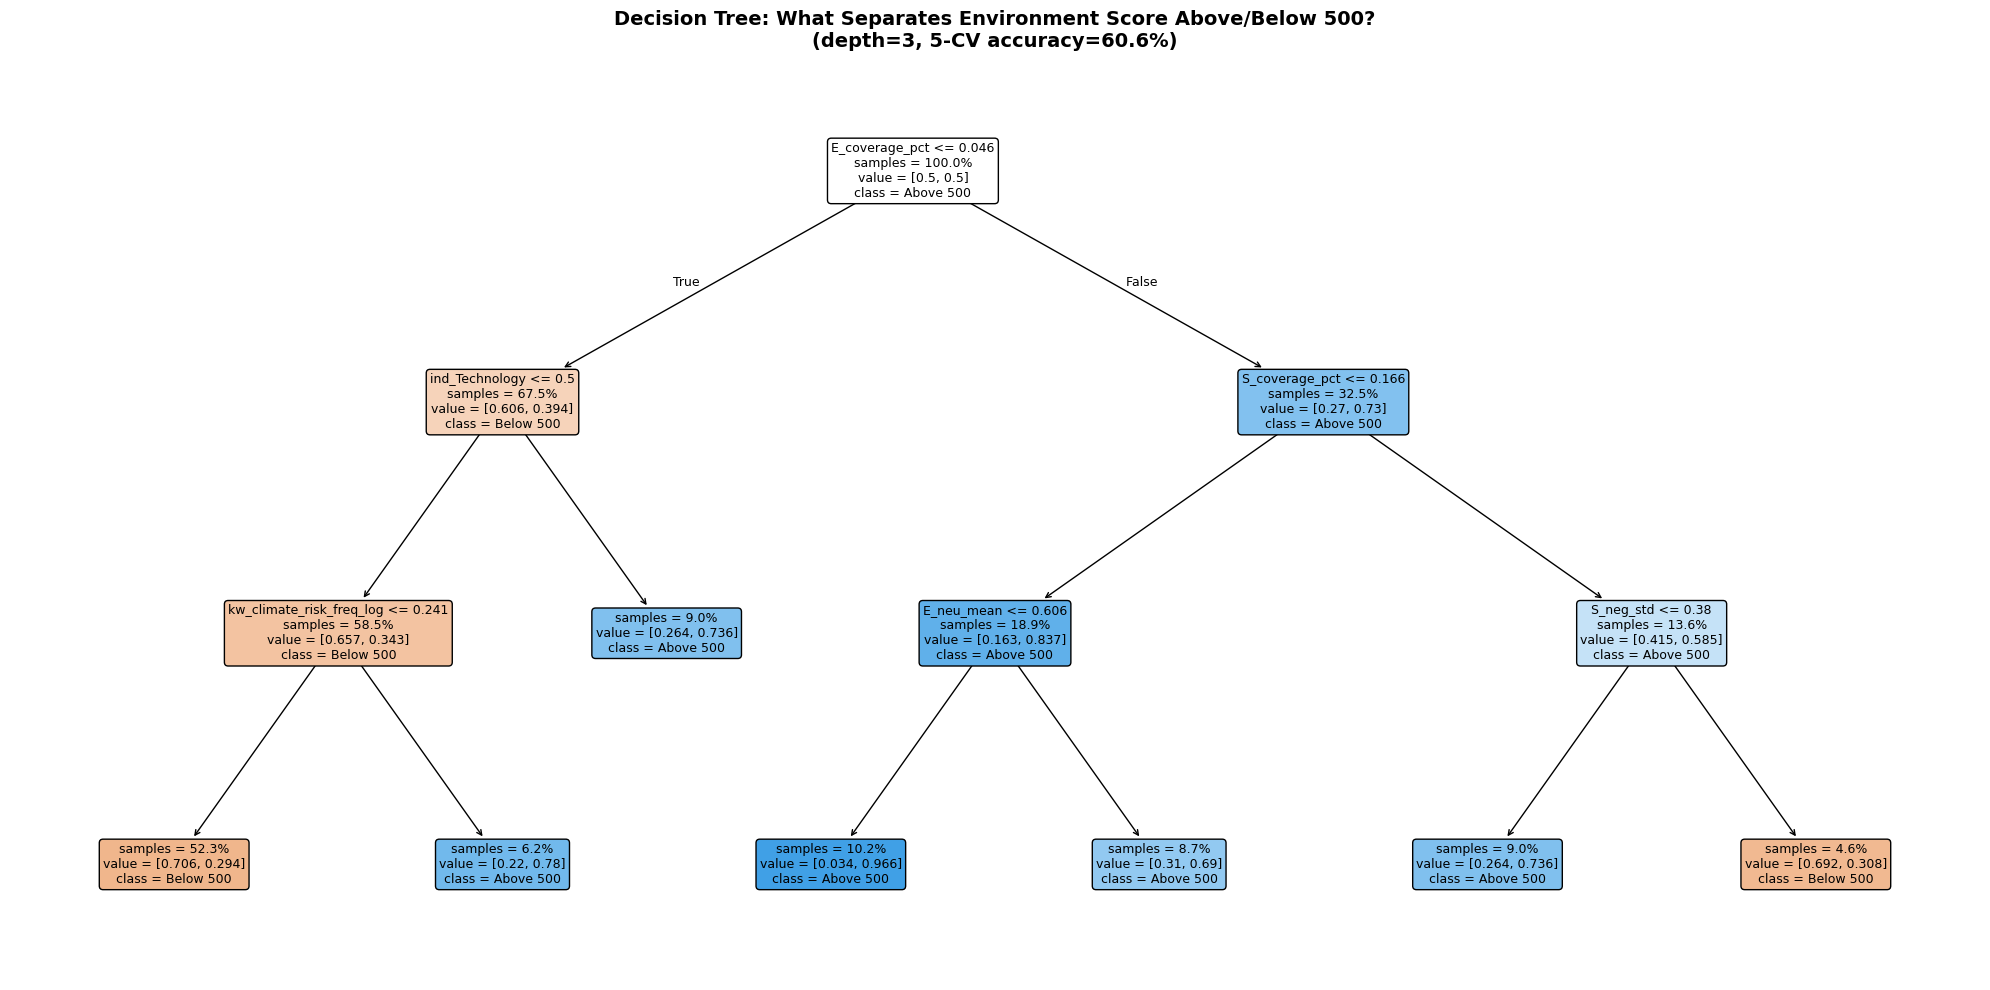


Features used in tree splits (6 of 103):

  E_coverage_pct                                importance = 0.3883
  kw_climate_risk_freq_log                      importance = 0.2022
  ind_Technology                                importance = 0.1869
  S_neg_std                                     importance = 0.0898
  S_coverage_pct                                importance = 0.0778
  E_neu_mean                                    importance = 0.0548

Deeper tree (depth=5) — 5-fold CV accuracy: 0.566 ± 0.071

Classification Report (depth=5, full dataset — for rule inspection):

              precision    recall  f1-score   support

   Below 500       0.73      0.89      0.80       152
   Above 500       0.88      0.71      0.79       171

    accuracy                           0.80       323
   macro avg       0.81      0.80      0.80       323
weighted avg       0.81      0.80      0.79       323



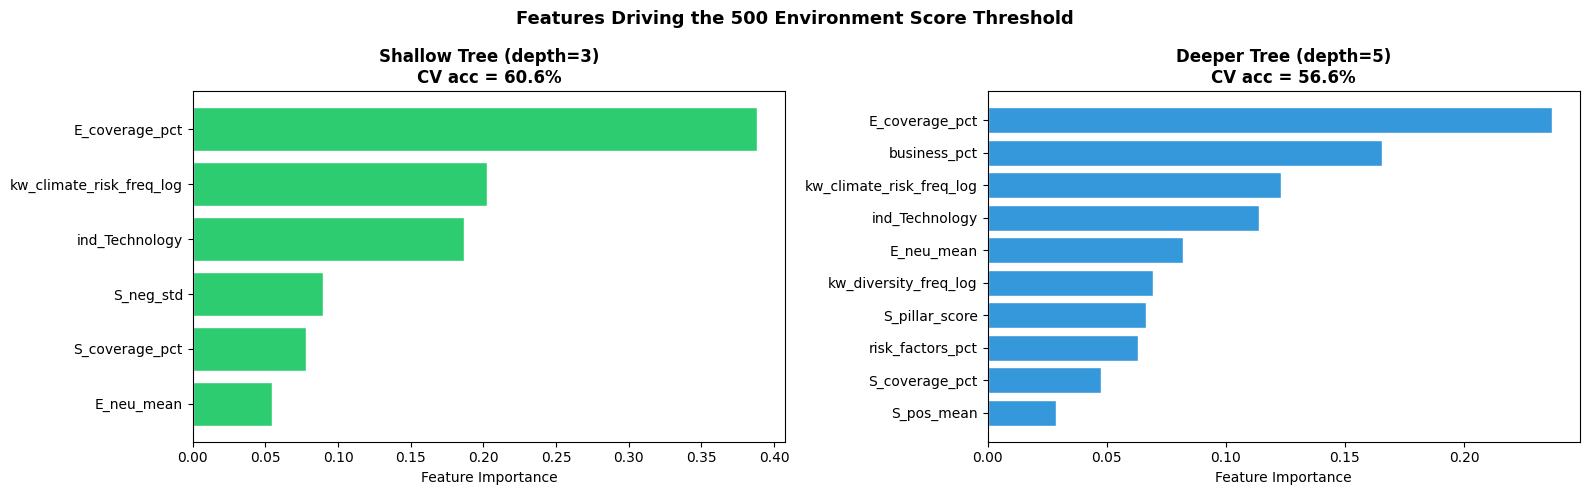


KEY FINDING — Disclosure Threshold Rules
  Node 0: if E_coverage_pct <= 0.0464  (n=323)
  Node 1: if ind_Technology <= 0.5000  (n=218)
  Node 2: if kw_climate_risk_freq_log <= 0.2412  (n=189)
  Node 6: if S_coverage_pct <= 0.1664  (n=105)
  Node 7: if E_neu_mean <= 0.6064  (n=61)
  Node 10: if S_neg_std <= 0.3802  (n=44)


In [33]:
# ══════════════════════════════════════════════════════════════════════════════
# Step 7.8 — Disclosure Threshold Analysis
# ══════════════════════════════════════════════════════════════════════════════
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

THRESHOLD = 500
feature_cols = new_feature_cols

# ── 1. Build binary target ───────────────────────────────────────────────────
y_binary = (engineered_df['environment_score'] >= THRESHOLD).astype(int)
X_disc = engineered_df[feature_cols].fillna(0)

print(f"Disclosure threshold classification (environment_score >= {THRESHOLD})")
print(f"  Above threshold: {y_binary.sum()} companies ({y_binary.mean():.1%})")
print(f"  Below threshold: {(~y_binary.astype(bool)).sum()} companies ({1 - y_binary.mean():.1%})")
print(f"  Features: {len(feature_cols)}")
print()

# ── 2. Fit shallow decision tree (depth 3 — interpretable) ──────────────────
dt_shallow = DecisionTreeClassifier(
    max_depth=3, min_samples_leaf=15, random_state=42, class_weight='balanced'
)
dt_shallow.fit(X_disc, y_binary)

# Cross-validate to check this isn't overfit
cv_scores = cross_val_score(
    DecisionTreeClassifier(max_depth=3, min_samples_leaf=15, random_state=42,
                           class_weight='balanced'),
    X_disc, y_binary, cv=5, scoring='accuracy'
)
print(f"Shallow tree (depth=3) — 5-fold CV accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print()

# ── 3. Print the decision rules ─────────────────────────────────────────────
print("Decision Rules (depth=3):")
print("=" * 60)
print(export_text(dt_shallow, feature_names=feature_cols, max_depth=3))

# ── 4. Visualize the tree ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    dt_shallow, feature_names=feature_cols, class_names=['Below 500', 'Above 500'],
    filled=True, rounded=True, ax=ax, fontsize=9, proportion=True,
    impurity=False
)
ax.set_title(
    f'Decision Tree: What Separates Environment Score Above/Below {THRESHOLD}?\n'
    f'(depth=3, 5-CV accuracy={cv_scores.mean():.1%})',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.show()

# ── 5. Feature importance from the tree ──────────────────────────────────────
tree_importance = pd.Series(
    dt_shallow.feature_importances_, index=feature_cols
).sort_values(ascending=False)

top_tree_feats = tree_importance[tree_importance > 0]
print(f"\nFeatures used in tree splits ({len(top_tree_feats)} of {len(feature_cols)}):\n")
for feat, imp in top_tree_feats.items():
    print(f"  {feat:<45} importance = {imp:.4f}")

# ── 6. Deeper tree for comparison (depth 5) ─────────────────────────────────
dt_deeper = DecisionTreeClassifier(
    max_depth=5, min_samples_leaf=10, random_state=42, class_weight='balanced'
)
dt_deeper.fit(X_disc, y_binary)

cv_deep = cross_val_score(
    DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, random_state=42,
                           class_weight='balanced'),
    X_disc, y_binary, cv=5, scoring='accuracy'
)
print(f"\nDeeper tree (depth=5) — 5-fold CV accuracy: {cv_deep.mean():.3f} ± {cv_deep.std():.3f}")

# Classification report on full dataset (training set — for rule discovery, not generalization)
y_pred_deep = dt_deeper.predict(X_disc)
print(f"\nClassification Report (depth=5, full dataset — for rule inspection):\n")
print(classification_report(y_binary, y_pred_deep, target_names=['Below 500', 'Above 500']))

# ── 7. Compare the top features across both trees ───────────────────────────
deep_importance = pd.Series(
    dt_deeper.feature_importances_, index=feature_cols
).sort_values(ascending=False)

top_deep = deep_importance[deep_importance > 0].head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Shallow tree importances
top_shallow = tree_importance[tree_importance > 0]
axes[0].barh(top_shallow.index[::-1], top_shallow.values[::-1], color='#2ecc71', edgecolor='white')
axes[0].set_title(f'Shallow Tree (depth=3)\nCV acc = {cv_scores.mean():.1%}', fontweight='bold')
axes[0].set_xlabel('Feature Importance')

# Deeper tree importances
axes[1].barh(top_deep.index[::-1], top_deep.values[::-1], color='#3498db', edgecolor='white')
axes[1].set_title(f'Deeper Tree (depth=5)\nCV acc = {cv_deep.mean():.1%}', fontweight='bold')
axes[1].set_xlabel('Feature Importance')

plt.suptitle(f'Features Driving the {THRESHOLD} Environment Score Threshold',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 8. Extract the specific threshold values from the shallow tree ───────────
print("\n" + "=" * 60)
print("KEY FINDING — Disclosure Threshold Rules")
print("=" * 60)
tree = dt_shallow.tree_
for node_id in range(tree.node_count):
    if tree.children_left[node_id] != tree.children_right[node_id]:  # not a leaf
        feat_name = feature_cols[tree.feature[node_id]]
        threshold_val = tree.threshold[node_id]
        n_samples = tree.n_node_samples[node_id]
        print(f"  Node {node_id}: if {feat_name} <= {threshold_val:.4f}  (n={n_samples})")

# **Step 8 - Model Training**

Train Ridge Regression and XGBoost models to predict ESG scores.

In [34]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from xgboost import XGBRegressor
    HAS_XGBOOST = True
except ImportError:
    print("XGBoost not installed. Using only Ridge regression.")
    HAS_XGBOOST = False

print("Model imports complete.")

Model imports complete.


In [35]:
def prepare_modeling_data(df, target="total_score"):
    """Select engineered features and target from engineered_df."""
    exclude_cols = ['ticker', 'industry', 'environment_score', 'social_score',
                    'governance_score', 'total_score', 'total_grade']
    feature_cols = [c for c in df.columns if c not in exclude_cols]

    X = df[feature_cols].fillna(0)
    y = df[target]
    return X, y, feature_cols

if len(engineered_df) > 0:
    X, y, feature_cols = prepare_modeling_data(engineered_df, target="total_score")
    print(f"Feature matrix: {X.shape}")
    print(f"Target: {y.shape}")
    print(f"\nFeature groups in engineered set:")
    print(f"  FinBERT sentiment:          {sum(1 for c in feature_cols if c.split('_')[0] in ('E','S','G') and not c.startswith('ind'))}")
    print(f"  Keyword freq (log):         {sum(1 for c in feature_cols if c.endswith('_freq_log'))}")
    print(f"  Keyword presence (partial): {sum(1 for c in feature_cols if c.endswith('_present'))}")
    print(f"  Document structure:         {sum(1 for c in feature_cols if c in ['doc_length','business_length','risk_factors_length','mda_length','business_pct','risk_factors_pct','mda_pct','E_coverage_pct','S_coverage_pct','G_coverage_pct'])}")
    print(f"  Quantitative signals:       {sum(1 for c in feature_cols if c.startswith('has_') or c.startswith('count_'))}")
    print(f"  Industry dummies:           {sum(1 for c in feature_cols if c.startswith('ind_'))}")

Feature matrix: (323, 108)
Target: (323,)

Feature groups in engineered set:
  FinBERT sentiment:          27
  Keyword freq (log):         14
  Keyword presence (partial): 8
  Document structure:         10
  Quantitative signals:       9
  Industry dummies:           38


In [36]:
def train_and_evaluate(X, y, feature_cols):
    """Train Ridge, Lasso, ElasticNet, and XGBoost on the engineered feature set with 5-fold CV."""
    from sklearn.model_selection import cross_val_score
    from sklearn.linear_model import Ridge, LassoCV, ElasticNetCV

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    results = {}

    # ── Scaling for linear models ─────────────────────────────────────────────
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    # ── Ridge Regression ──────────────────────────────────────────────────────
    ridge = Ridge(alpha=50.0)
    ridge.fit(X_train_scaled, y_train)
    ridge_pred = ridge.predict(X_test_scaled)

    ridge_cv = cross_val_score(
        Ridge(alpha=50.0), X_train_scaled, y_train, cv=5, scoring='r2'
    )

    results['ridge'] = {
        'model': ridge, 'scaler': scaler,
        'r2':   r2_score(y_test, ridge_pred),
        'mae':  mean_absolute_error(y_test, ridge_pred),
        'rmse': mean_squared_error(y_test, ridge_pred) ** 0.5,
        'cv_r2_mean': ridge_cv.mean(),
        'cv_r2_std':  ridge_cv.std(),
        'coefficients': dict(zip(feature_cols, ridge.coef_)),
    }

    # ── Lasso with LassoCV (automatic alpha selection) ────────────────────────
    # LassoCV tests 100 alpha values internally using 5-fold CV to find the
    # best regularisation strength. L1 penalty drives weak features to exactly
    # zero, performing automatic feature selection.
    lasso_cv_model = LassoCV(cv=5, random_state=42, max_iter=10000)
    lasso_cv_model.fit(X_train_scaled, y_train)
    lasso_pred = lasso_cv_model.predict(X_test_scaled)

    # Re-run CV at the selected alpha for consistent reporting
    from sklearn.linear_model import Lasso
    lasso_cv_scores = cross_val_score(
        Lasso(alpha=lasso_cv_model.alpha_, max_iter=10000),
        X_train_scaled, y_train, cv=5, scoring='r2'
    )

    n_nonzero = np.sum(lasso_cv_model.coef_ != 0)
    results['lasso'] = {
        'model': lasso_cv_model, 'scaler': scaler,
        'r2':   r2_score(y_test, lasso_pred),
        'mae':  mean_absolute_error(y_test, lasso_pred),
        'rmse': mean_squared_error(y_test, lasso_pred) ** 0.5,
        'cv_r2_mean': lasso_cv_scores.mean(),
        'cv_r2_std':  lasso_cv_scores.std(),
        'best_alpha': lasso_cv_model.alpha_,
        'n_nonzero':  n_nonzero,
        'coefficients': dict(zip(feature_cols, lasso_cv_model.coef_)),
    }

    # ── ElasticNet with ElasticNetCV (automatic alpha + l1_ratio selection) ───
    # ElasticNet blends L1 (Lasso) and L2 (Ridge) penalties. ElasticNetCV
    # searches over both alpha and l1_ratio to find the best mix.
    enet_cv_model = ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99],
        cv=5, random_state=42, max_iter=10000
    )
    enet_cv_model.fit(X_train_scaled, y_train)
    enet_pred = enet_cv_model.predict(X_test_scaled)

    from sklearn.linear_model import ElasticNet
    enet_cv_scores = cross_val_score(
        ElasticNet(alpha=enet_cv_model.alpha_, l1_ratio=enet_cv_model.l1_ratio_,
                   max_iter=10000),
        X_train_scaled, y_train, cv=5, scoring='r2'
    )

    n_nonzero_enet = np.sum(enet_cv_model.coef_ != 0)
    results['elasticnet'] = {
        'model': enet_cv_model, 'scaler': scaler,
        'r2':   r2_score(y_test, enet_pred),
        'mae':  mean_absolute_error(y_test, enet_pred),
        'rmse': mean_squared_error(y_test, enet_pred) ** 0.5,
        'cv_r2_mean': enet_cv_scores.mean(),
        'cv_r2_std':  enet_cv_scores.std(),
        'best_alpha':    enet_cv_model.alpha_,
        'best_l1_ratio': enet_cv_model.l1_ratio_,
        'n_nonzero':     n_nonzero_enet,
        'coefficients':  dict(zip(feature_cols, enet_cv_model.coef_)),
    }

    # ── XGBoost Regressor ─────────────────────────────────────────────────────
    if HAS_XGBOOST:
        xgb = XGBRegressor(
            n_estimators=300,
            max_depth=3,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.7,
            reg_lambda=5,
            reg_alpha=1,
            random_state=42,
            verbosity=0,
        )
        xgb.fit(X_train, y_train,
                eval_set=[(X_test, y_test)],
                verbose=False)
        xgb_pred = xgb.predict(X_test)

        xgb_cv = cross_val_score(
            XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.05,
                         subsample=0.8, colsample_bytree=0.7,
                         reg_lambda=5, reg_alpha=1, random_state=42, verbosity=0),
            X_train, y_train, cv=5, scoring='r2'
        )

        results['xgboost'] = {
            'model': xgb,
            'r2':   r2_score(y_test, xgb_pred),
            'mae':  mean_absolute_error(y_test, xgb_pred),
            'rmse': mean_squared_error(y_test, xgb_pred) ** 0.5,
            'cv_r2_mean': xgb_cv.mean(),
            'cv_r2_std':  xgb_cv.std(),
            'feature_importance': dict(zip(feature_cols, xgb.feature_importances_)),
        }

    results['X_test'] = X_test
    results['y_test'] = y_test
    return results


if len(engineered_df) > 0:
    print(f"Training models on total_score  ({X.shape[0]} samples, {X.shape[1]} features)...\n")
    model_results = train_and_evaluate(X, y, feature_cols)

    print(f"{'Model':<22} {'Test R²':>8} {'Test MAE':>10} {'5-CV R² mean':>14} {'± std':>8}")
    print("-" * 66)
    for name, res in model_results.items():
        if isinstance(res, dict) and 'r2' in res:
            label = name.replace('_', ' ').title()
            print(f"{label:<22} {res['r2']:>8.4f} {res['mae']:>10.2f} "
                  f"{res['cv_r2_mean']:>14.4f} {res['cv_r2_std']:>8.4f}")

    # Print Lasso/ElasticNet details
    if 'lasso' in model_results:
        res = model_results['lasso']
        print(f"\nLasso details:      alpha={res['best_alpha']:.4f}, "
              f"non-zero features={res['n_nonzero']}/{len(feature_cols)}")
    if 'elasticnet' in model_results:
        res = model_results['elasticnet']
        print(f"ElasticNet details: alpha={res['best_alpha']:.4f}, "
              f"l1_ratio={res['best_l1_ratio']:.2f}, "
              f"non-zero features={res['n_nonzero']}/{len(feature_cols)}")

Training models on total_score  (323 samples, 108 features)...

Model                   Test R²   Test MAE   5-CV R² mean    ± std
------------------------------------------------------------------
Ridge                   -0.3258     164.93        -0.0251   0.1106
Lasso                    0.0308     147.57         0.1862   0.0635
Elasticnet               0.0646     145.67         0.1936   0.0551
Xgboost                  0.0464     145.61         0.0837   0.1220

Lasso details:      alpha=13.9867, non-zero features=22/108
ElasticNet details: alpha=14.1279, l1_ratio=0.99, non-zero features=28/108


# **Step 9 - Feature Importance Analysis**

Analyze which features are most important for predicting ESG scores.

Ridge Regression - Top Feature Coefficients



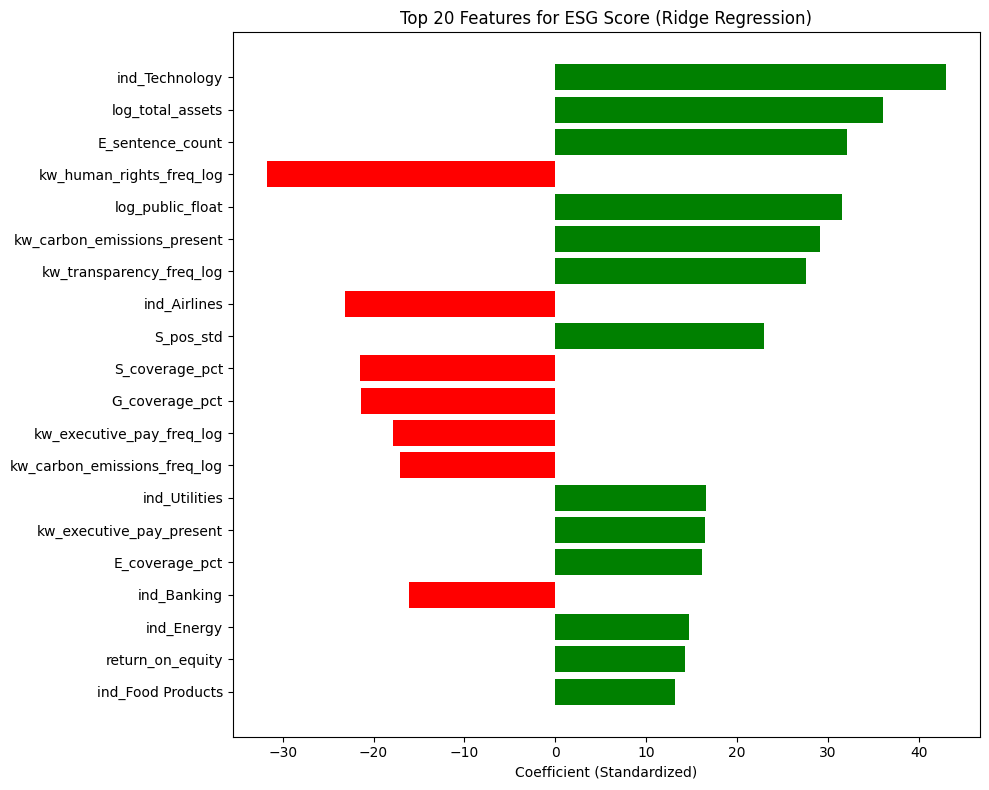

In [37]:
def plot_ridge_coefficients(coefficients, top_n=20):
    """Plot top Ridge regression coefficients."""
    coef_df = pd.DataFrame({
        'feature': list(coefficients.keys()),
        'coefficient': list(coefficients.values())
    }).sort_values('coefficient', key=abs, ascending=False)
    
    top = coef_df.head(top_n)
    colors = ['green' if c > 0 else 'red' for c in top['coefficient']]
    
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(top['feature'], top['coefficient'], color=colors)
    ax.set_xlabel('Coefficient (Standardized)')
    ax.set_title(f'Top {top_n} Features for ESG Score (Ridge Regression)')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    return coef_df

if 'model_results' in dir() and 'ridge' in model_results:
    print("Ridge Regression - Top Feature Coefficients\n")
    coef_df = plot_ridge_coefficients(model_results['ridge']['coefficients'])

XGBoost - Feature Importance



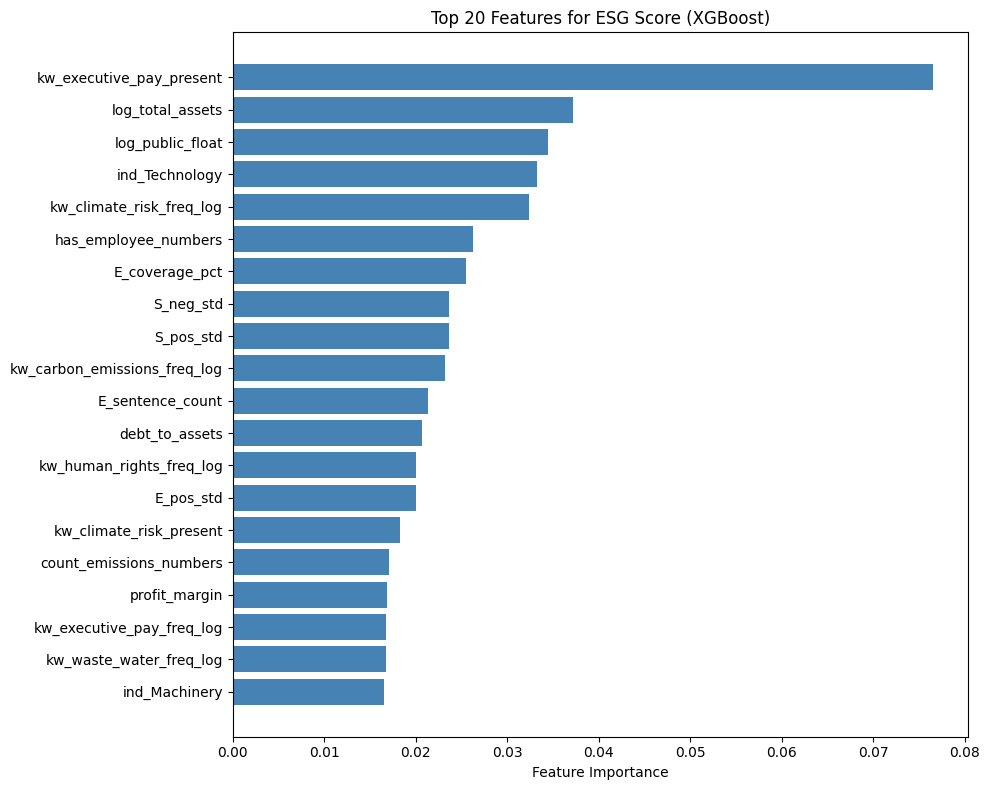

In [38]:
def plot_xgboost_importance(feature_importance, top_n=20):
    """Plot XGBoost feature importance."""
    imp_df = pd.DataFrame({
        'feature': list(feature_importance.keys()),
        'importance': list(feature_importance.values())
    }).sort_values('importance', ascending=False)
    
    top = imp_df.head(top_n)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(top['feature'], top['importance'], color='steelblue')
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'Top {top_n} Features for ESG Score (XGBoost)')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    return imp_df

if 'model_results' in dir() and 'xgboost' in model_results:
    print("XGBoost - Feature Importance\n")
    imp_df = plot_xgboost_importance(model_results['xgboost']['feature_importance'])

# **Step 10 - SHAP Analysis**

Use SHAP values to explain model predictions.

In [39]:
try:
    import shap
    HAS_SHAP = True
    print("SHAP library loaded.")
except ImportError:
    print("SHAP not installed. Run: pip install shap")
    HAS_SHAP = False

SHAP library loaded.


In [40]:
if HAS_SHAP and 'model_results' in dir() and 'xgboost' in model_results:
    print("Computing SHAP values for XGBoost model...")
    
    xgb_model = model_results['xgboost']['model']
    X_test = model_results['X_test']
    
    # Create SHAP explainer
    explainer = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(X_test)
    
    print("SHAP values computed.")

Computing SHAP values for XGBoost model...
SHAP values computed.


SHAP Summary Plot - Feature Importance + Direction



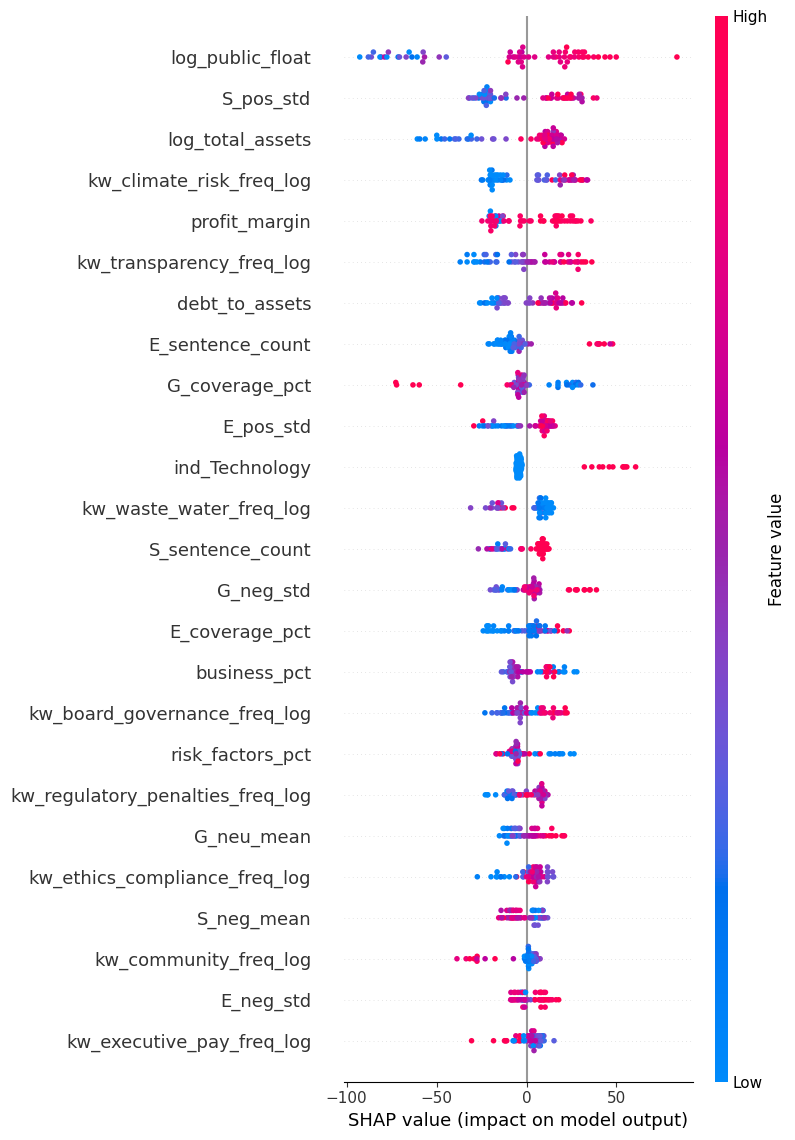

In [41]:
if HAS_SHAP and 'shap_values' in dir():
    print("SHAP Summary Plot - Feature Importance + Direction\n")
    shap.summary_plot(shap_values, X_test, feature_names=feature_cols, max_display=25)

SHAP Bar Plot - Mean Absolute SHAP Values



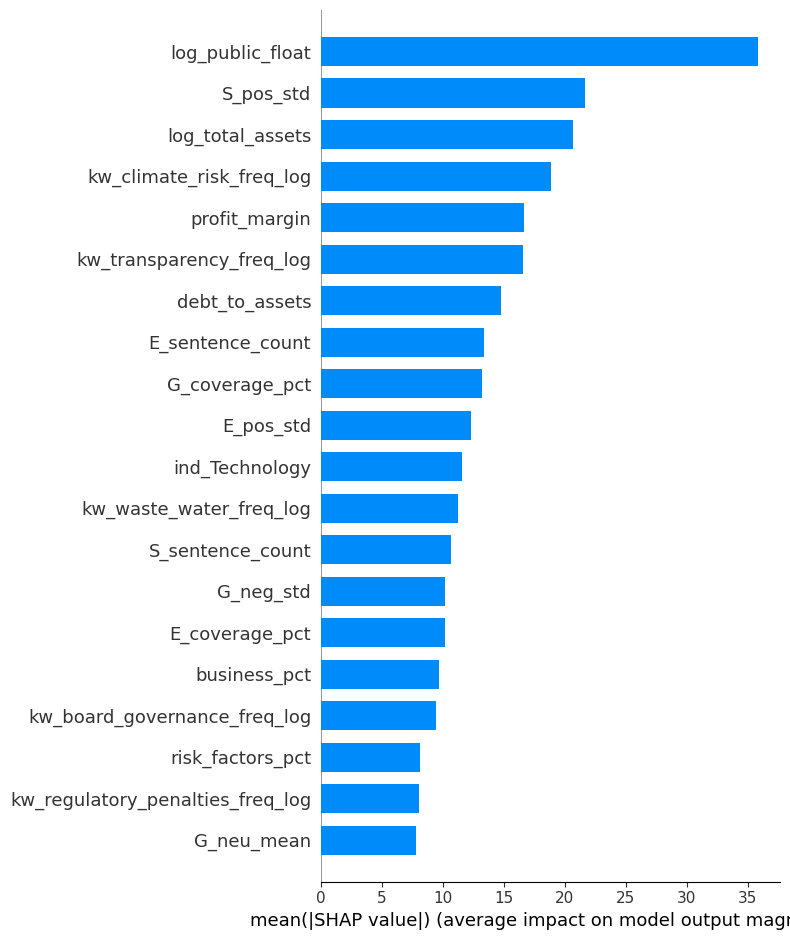

In [42]:
if HAS_SHAP and 'shap_values' in dir():
    print("SHAP Bar Plot - Mean Absolute SHAP Values\n")
    shap.summary_plot(shap_values, X_test, feature_names=feature_cols, 
                      plot_type="bar", max_display=20)

SHAP Waterfall Plot - Single Prediction Explanation



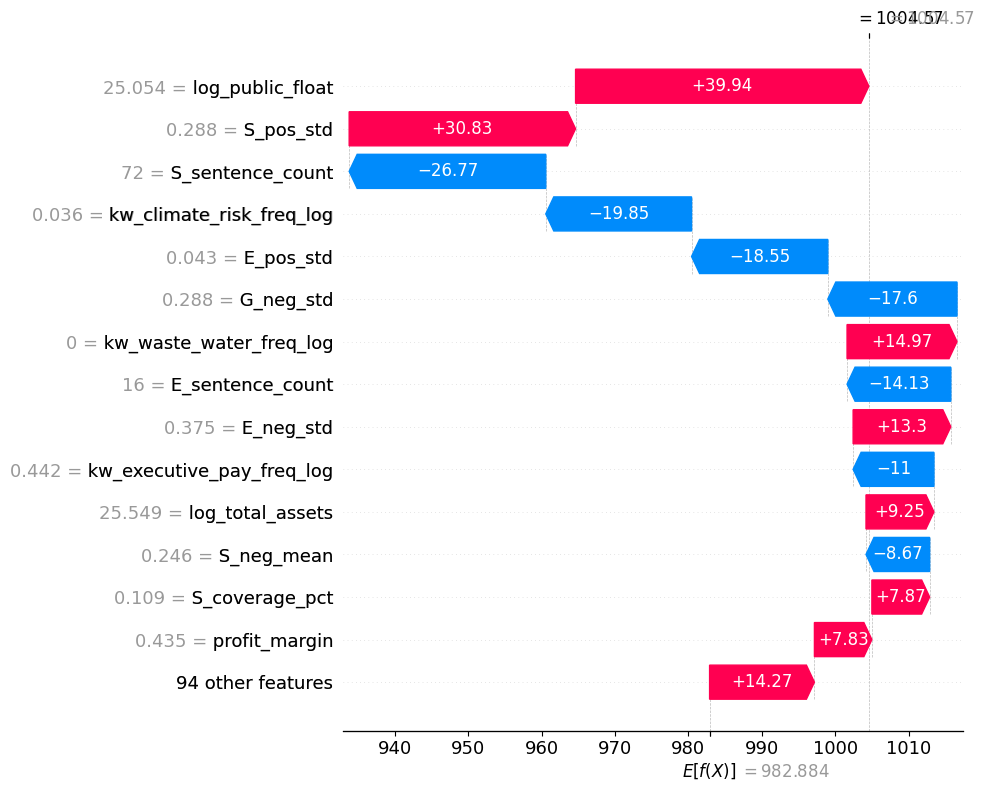

In [43]:
if HAS_SHAP and 'shap_values' in dir() and 'explainer' in dir():
    print("SHAP Waterfall Plot - Single Prediction Explanation\n")
    # Show explanation for first test sample
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[0],
            base_values=explainer.expected_value,
            data=X_test.iloc[0],
            feature_names=feature_cols
        ),
        max_display=15
    )

# **Step 11 - Per-Pillar Analysis**

Train separate models for Environment, Social, and Governance scores.

In [44]:
def train_pillar_models(df, feature_cols):
    """Train XGBoost models for each ESG pillar using the engineered feature set."""
    from sklearn.model_selection import cross_val_score

    pillar_results = {}

    for target in ['environment_score', 'social_score', 'governance_score']:
        print(f"\n{'='*50}")
        print(f"Training model for: {target}")
        print(f"{'='*50}")

        X_p = df[feature_cols].fillna(0)
        y_p = df[target]

        X_train, X_test, y_train, y_test = train_test_split(
            X_p, y_p, test_size=0.2, random_state=42
        )

        if HAS_XGBOOST:
            model = XGBRegressor(
                n_estimators=300,
                max_depth=3,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.7,
                reg_lambda=5,
                reg_alpha=1,
                random_state=42,
                verbosity=0,
            )
            model.fit(X_train, y_train)
            pred = model.predict(X_test)

            cv_scores = cross_val_score(
                XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.05,
                             subsample=0.8, colsample_bytree=0.7,
                             reg_lambda=5, reg_alpha=1, random_state=42, verbosity=0),
                X_train, y_train, cv=5, scoring='r2'
            )

            r2  = r2_score(y_test, pred)
            mae = mean_absolute_error(y_test, pred)
            print(f"  Test  R²: {r2:.4f}   MAE: {mae:.2f}")
            print(f"  5-CV  R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

            pillar_results[target] = {
                'model': model,
                'r2': r2, 'mae': mae,
                'cv_r2_mean': cv_scores.mean(),
                'cv_r2_std':  cv_scores.std(),
                'X_test': X_test, 'y_test': y_test,
            }

    return pillar_results


if len(engineered_df) > 0:
    pillar_results = train_pillar_models(engineered_df, feature_cols)


Training model for: environment_score
  Test  R²: 0.0468   MAE: 97.93
  5-CV  R²: 0.1004 ± 0.1411

Training model for: social_score
  Test  R²: -0.0597   MAE: 36.22
  5-CV  R²: 0.1090 ± 0.1147

Training model for: governance_score
  Test  R²: -0.0288   MAE: 35.37
  5-CV  R²: -0.0808 ± 0.0764



SHAP Analysis: environment_score



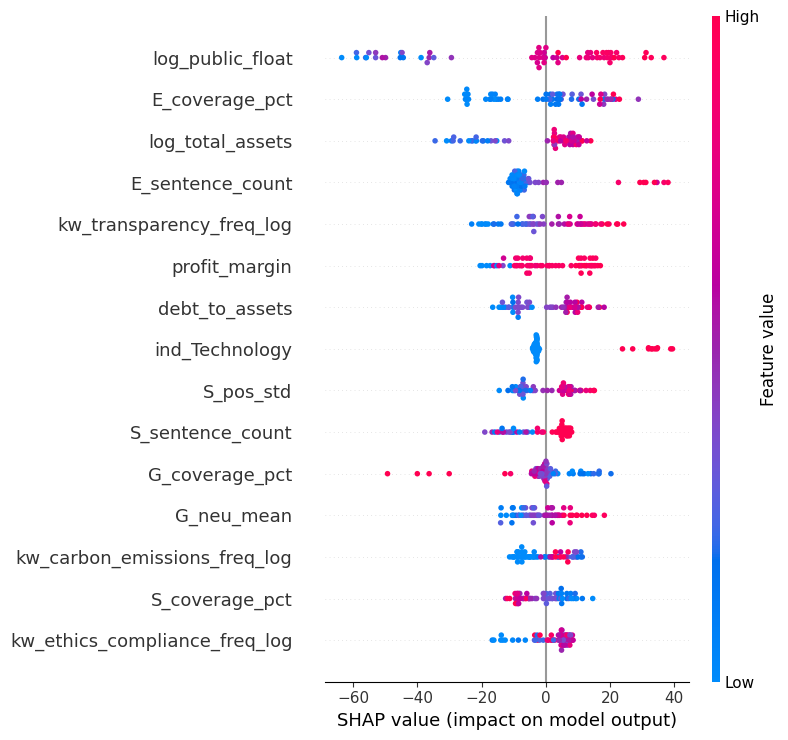


SHAP Analysis: social_score



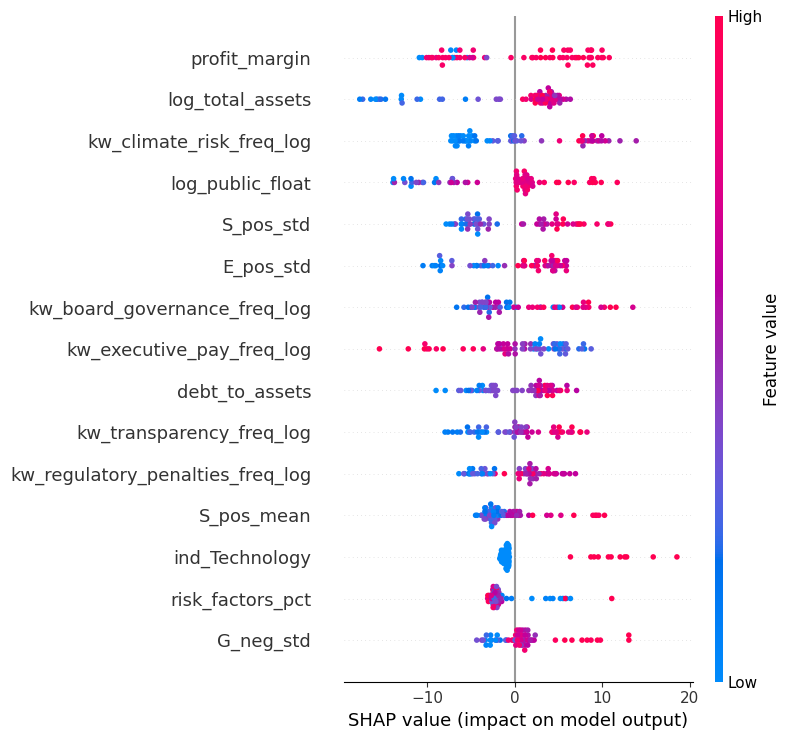


SHAP Analysis: governance_score



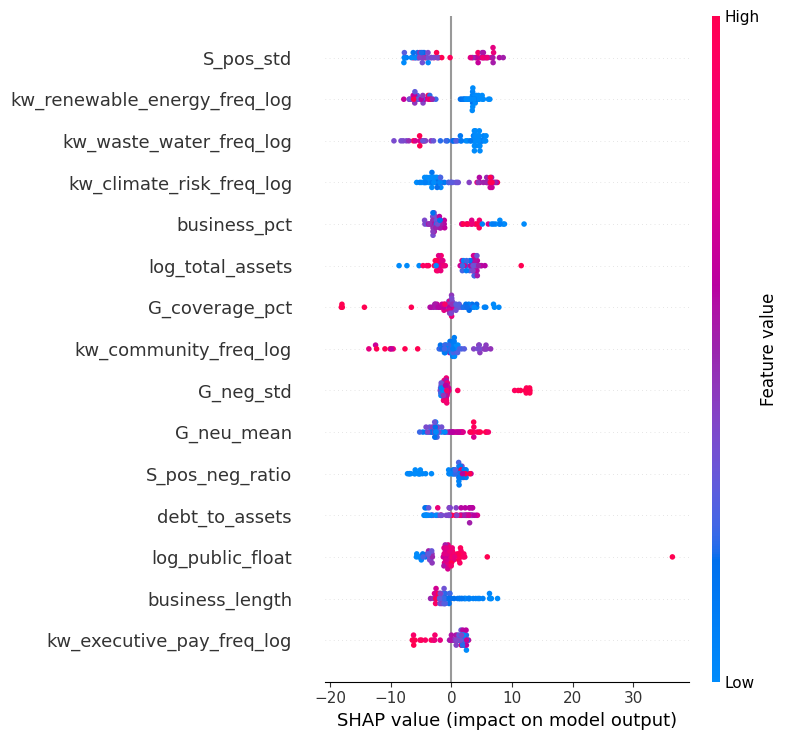

In [45]:
if HAS_SHAP and 'pillar_results' in dir():
    for target, results in pillar_results.items():
        print(f"\n{'='*50}")
        print(f"SHAP Analysis: {target}")
        print(f"{'='*50}\n")
        
        explainer = shap.TreeExplainer(results['model'])
        shap_values = explainer.shap_values(results['X_test'])
        
        shap.summary_plot(
            shap_values, 
            results['X_test'], 
            feature_names=feature_cols, 
            max_display=15,
            show=True
        )

# **Step 12 - Results Summary**

Summarize key findings and expected relationships.

In [46]:
print("=" * 60)
print("RESULTS SUMMARY â€” Engineered Feature Set")
print("=" * 60)

if 'model_results' in dir():
    print("\n--- Total ESG Score (Regression) ---")
    print(f"{'Model':<20} {'Test R²':>8} {'Test MAE':>10} {'5-CV R²':>10} {'± std':>8}")
    print("-" * 58)
    for name, res in model_results.items():
        if isinstance(res, dict) and 'r2' in res:
            label = name.replace('_', ' ').title()
            print(f"{label:<20} {res['r2']:>8.4f} {res['mae']:>10.2f} "
                  f"{res['cv_r2_mean']:>10.4f} {res['cv_r2_std']:>8.4f}")

if 'pillar_results' in dir():
    print("\n--- Per-Pillar Prediction (XGBoost) ---")
    print(f"{'Pillar':<20} {'Test R²':>8} {'Test MAE':>10} {'5-CV R²':>10} {'± std':>8}")
    print("-" * 58)
    for target, res in pillar_results.items():
        label = target.replace('_score', '').title()
        print(f"{label:<20} {res['r2']:>8.4f} {res['mae']:>10.2f} "
              f"{res['cv_r2_mean']:>10.4f} {res['cv_r2_std']:>8.4f}")

RESULTS SUMMARY â€” Engineered Feature Set

--- Total ESG Score (Regression) ---
Model                 Test R²   Test MAE    5-CV R²    ± std
----------------------------------------------------------
Ridge                 -0.3258     164.93    -0.0251   0.1106
Lasso                  0.0308     147.57     0.1862   0.0635
Elasticnet             0.0646     145.67     0.1936   0.0551
Xgboost                0.0464     145.61     0.0837   0.1220

--- Per-Pillar Prediction (XGBoost) ---
Pillar                Test R²   Test MAE    5-CV R²    ± std
----------------------------------------------------------
Environment            0.0468      97.93     0.1004   0.1411
Social                -0.0597      36.22     0.1090   0.1147
Governance            -0.0288      35.37    -0.0808   0.0764


In [47]:
# Save model results and feature importance
if 'model_results' in dir() and 'xgboost' in model_results:
    # Save feature importance
    importance_df = pd.DataFrame({
        'feature': list(model_results['xgboost']['feature_importance'].keys()),
        'importance': list(model_results['xgboost']['feature_importance'].values())
    }).sort_values('importance', ascending=False)
    
    importance_df.to_csv(os.path.join(OUTPUT_DIR, "feature_importance.csv"), index=False)
    print(f"Feature importance saved to {OUTPUT_DIR}/feature_importance.csv")

if 'merged_df' in dir() and len(merged_df) > 0:
    merged_df.to_csv(os.path.join(OUTPUT_DIR, "merged_features_labels.csv"), index=False)
    print(f"Merged dataset saved to {OUTPUT_DIR}/merged_features_labels.csv")

Feature importance saved to ../data/finbert_features/feature_importance.csv
Merged dataset saved to ../data/finbert_features/merged_features_labels.csv


---

## Threshold Analysis What Separates Companies Near Environment Score 500?

The environment score distribution is strongly bimodal with a sharp spike at ~500, suggesting raters apply a **decision rule** at that threshold. Companies just below 500 (400-499) and just at/above 500 (500-599) are otherwise similar in overall profile the goal here is to identify which specific features tip a company from one cluster to the other.

We use the already-trained `environment_score` XGBoost model to compute SHAP values across **all** companies in those two bands, then compare the SHAP attribution profiles to pinpoint the discriminating features.

In [48]:
# Setup: pull the environment_score model and build the full feature matrix
THRESHOLD = 500
BAND_LOW  = (400, 500)   # just below
BAND_HIGH = (500, 600)   # just at/above

if not HAS_SHAP:
    print("SHAP not installed â€” run: pip install shap")
elif 'pillar_results' not in dir() or 'environment_score' not in pillar_results:
    print("pillar_results not found â€” re-run the pillar-model cell first.")
else:
    env_model = pillar_results['environment_score']['model']

    # Full feature matrix (all companies, not just test split)
    X_all = engineered_df[feature_cols].fillna(0)
    y_all = engineered_df['environment_score']

    # Masks for the two narrow bands
    mask_low  = (y_all >= BAND_LOW[0])  & (y_all < BAND_LOW[1])
    mask_high = (y_all >= BAND_HIGH[0]) & (y_all < BAND_HIGH[1])

    X_low  = X_all[mask_low]
    X_high = X_all[mask_high]

    print(f"Companies in band {BAND_LOW[0]}-{BAND_LOW[1]-1}  (just below threshold): {mask_low.sum()}")
    print(f"Companies in band {BAND_HIGH[0]}-{BAND_HIGH[1]-1} (at/above threshold):  {mask_high.sum()}")
    print(f"\nComputing SHAP values for {len(X_low) + len(X_high)} threshold-band companies...")

    explainer_env = shap.TreeExplainer(env_model)

    shap_low  = explainer_env.shap_values(X_low)
    shap_high = explainer_env.shap_values(X_high)

    # DataFrames of SHAP values for easy manipulation
    shap_low_df  = pd.DataFrame(shap_low,  columns=feature_cols, index=X_low.index)
    shap_high_df = pd.DataFrame(shap_high, columns=feature_cols, index=X_high.index)

    print("Done.")

Companies in band 400-499  (just below threshold): 19
Companies in band 500-599 (at/above threshold):  157

Computing SHAP values for 176 threshold-band companies...
Done.


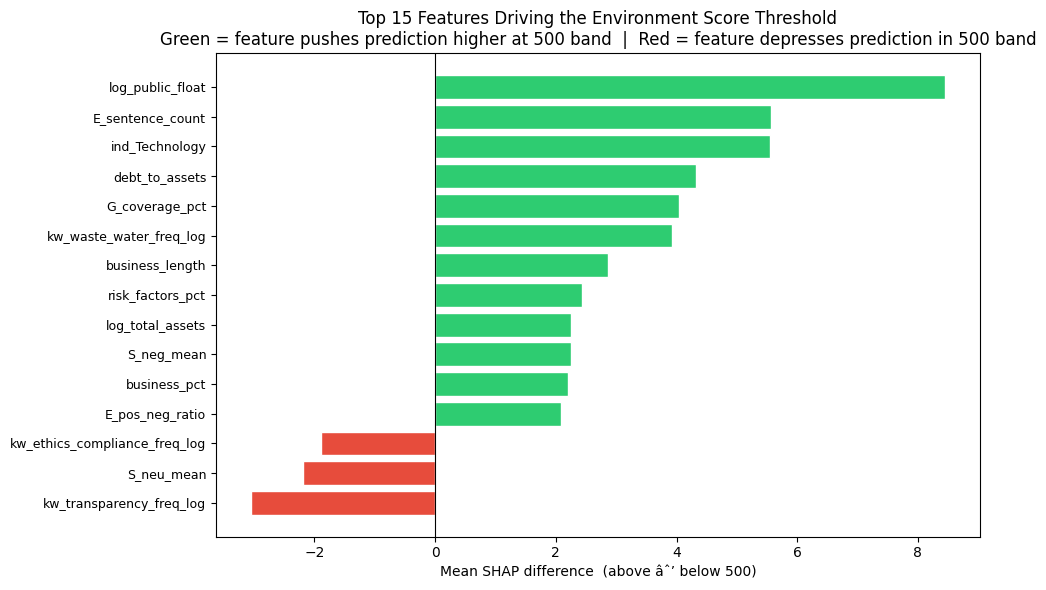


Top 15 features by SHAP shift across the 500 threshold:

                               mean_shap_below_500  mean_shap_above_500  shap_diff
log_public_float                            0.7101               9.1631     8.4530
E_sentence_count                           -3.7488               1.8120     5.5608
ind_Technology                             -2.9720               2.5773     5.5493
debt_to_assets                             -1.0008               3.3272     4.3280
G_coverage_pct                             -2.1829               1.8558     4.0387
kw_waste_water_freq_log                    -3.4498               0.4731     3.9229
business_length                             0.3361               3.1953     2.8592
risk_factors_pct                           -1.0547               1.3785     2.4333
log_total_assets                            2.5667               4.8196     2.2529
S_neg_mean                                 -1.2444               0.9999     2.2443
business_pct                 

In [49]:
# Mean SHAP difference: above-threshold minus below-threshold
if HAS_SHAP and 'shap_low_df' in dir():
    mean_shap_low  = shap_low_df.mean()
    mean_shap_high = shap_high_df.mean()
    shap_diff = mean_shap_high - mean_shap_low   # positive = pushes prediction UP at threshold

    top_n = 15
    top_idx = shap_diff.abs().sort_values(ascending=False).head(top_n).index
    top_diff = shap_diff[top_idx].sort_values()

    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in top_diff]
    ax.barh(top_diff.index, top_diff.values, color=colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Mean SHAP difference  (above âˆ’ below 500)')
    ax.set_title(
        f'Top {top_n} Features Driving the Environment Score Threshold\n'
        f'Green = feature pushes prediction higher at 500 band  |  '
        f'Red = feature depresses prediction in 500 band'
    )
    ax.tick_params(axis='y', labelsize=9)
    plt.tight_layout()
    plt.show()

    print(f"\nTop {top_n} features by SHAP shift across the 500 threshold:\n")
    summary = pd.DataFrame({
        'mean_shap_below_500': mean_shap_low[top_idx].round(4),
        'mean_shap_above_500': mean_shap_high[top_idx].round(4),
        'shap_diff': shap_diff[top_idx].round(4),
    }).loc[top_idx].sort_values('shap_diff', ascending=False)
    print(summary.to_string())

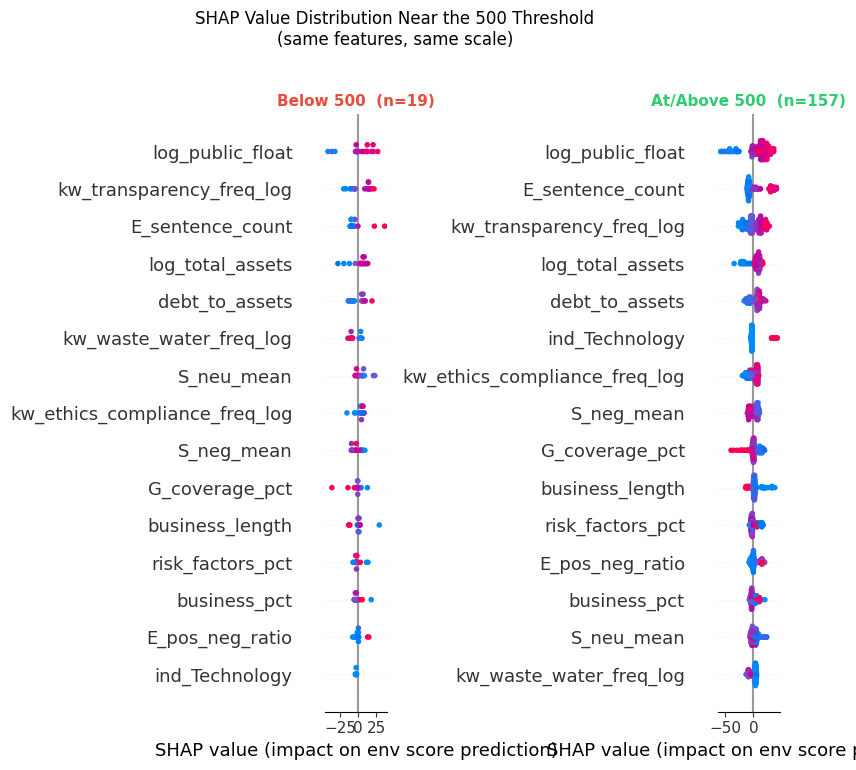

In [50]:
# â”€â”€ SHAP beeswarm for each band side-by-side â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
if HAS_SHAP and 'shap_low_df' in dir():
    # Restrict to the top discriminating features for clarity
    display_feats = top_idx.tolist()

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for ax, shap_arr, X_band, label, color in [
        (axes[0], shap_low,  X_low,  f'Below 500  (n={len(X_low)})',  '#e74c3c'),
        (axes[1], shap_high, X_high, f'At/Above 500  (n={len(X_high)})', '#2ecc71'),
    ]:
        feat_idx = [feature_cols.index(f) for f in display_feats]
        shap_sub = shap_arr[:, feat_idx]
        X_sub    = X_band[display_feats].values

        plt.sca(ax)
        shap.summary_plot(
            shap_sub,
            X_sub,
            feature_names=display_feats,
            plot_type='dot',
            show=False,
            color_bar=False,
        )
        ax.set_title(label, fontsize=11, color=color, fontweight='bold')
        ax.set_xlabel('SHAP value (impact on env score prediction)')

    plt.suptitle('SHAP Value Distribution Near the 500 Threshold\n(same features, same scale)',
                 fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

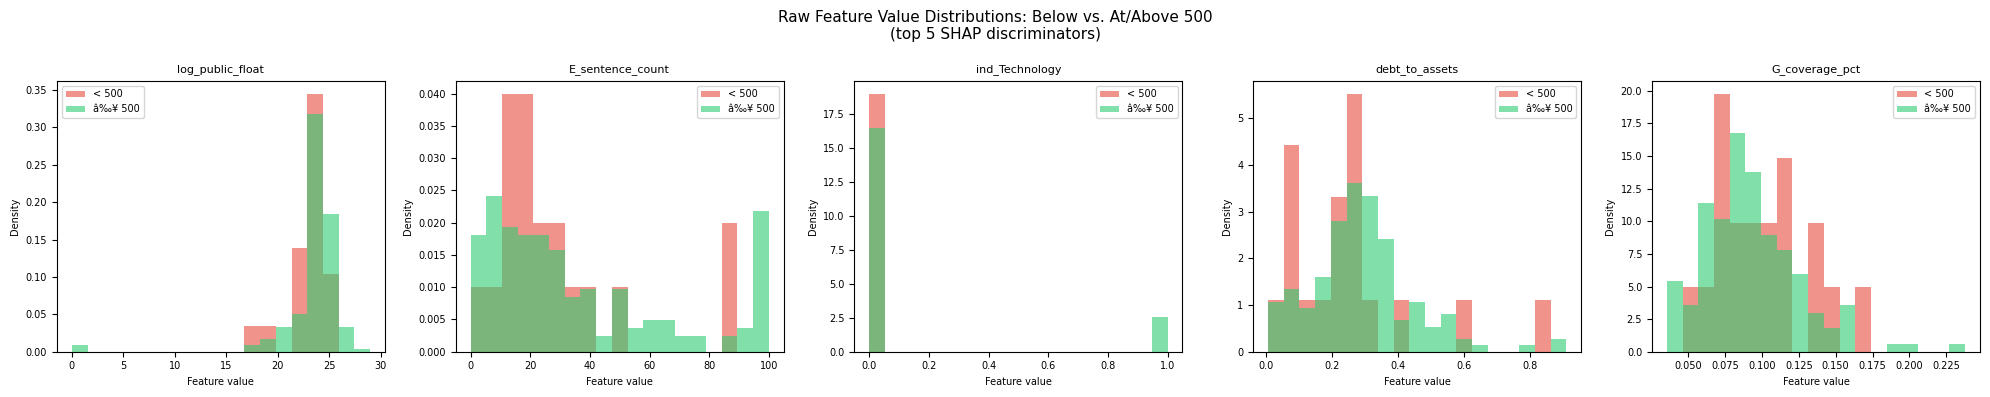

Mann-Whitney U tests â€” top discriminating features:

Feature                                           U-stat     p-value    Med(below)    Med(above)
-----------------------------------------------------------------------------------------------
log_public_float                                    1086      0.0532       23.2470       23.8915
E_sentence_count                                    1298      0.3584       19.0000       26.0000
ind_Technology                                      1292      0.0911        0.0000        0.0000
debt_to_assets                                      1128      0.0830        0.2156        0.2732
G_coverage_pct                                      1672      0.3908        0.0943        0.0887
kw_waste_water_freq_log                             1779      0.1618        0.1010        0.0442
kw_transparency_freq_log                            1762      0.1989        0.7078        0.5611
business_length                                     1483      0.9696     

In [ ]:
# â”€â”€ Raw feature value distributions for the top discriminating features â”€â”€â”€â”€â”€â”€â”€
if HAS_SHAP and 'shap_low_df' in dir():
    top5 = shap_diff.abs().sort_values(ascending=False).head(5).index.tolist()

    fig, axes = plt.subplots(1, len(top5), figsize=(4 * len(top5), 4))

    for ax, feat in zip(axes, top5):
        vals_low  = X_low[feat].values
        vals_high = X_high[feat].values

        bins = np.linspace(
            min(vals_low.min(), vals_high.min()),
            max(vals_low.max(), vals_high.max()),
            20
        )
        ax.hist(vals_low,  bins=bins, alpha=0.6, color='#e74c3c', label='< 500',  density=True)
        ax.hist(vals_high, bins=bins, alpha=0.6, color='#2ecc71', label='â‰¥ 500', density=True)

        ax.set_title(feat, fontsize=8)
        ax.set_xlabel('Feature value', fontsize=7)
        ax.set_ylabel('Density', fontsize=7)
        ax.tick_params(labelsize=7)
        ax.legend(fontsize=7)

    fig.suptitle('Raw Feature Value Distributions: Below vs. At/Above 500\n(top 5 SHAP discriminators)',
                 fontsize=11)
    plt.tight_layout()
    plt.show()

    # Statistical test for each top feature
    from scipy.stats import mannwhitneyu
    print("Mann-Whitney U tests â€” top discriminating features:\n")
    print(f"{'Feature':<45} {'U-stat':>10}  {'p-value':>10}  {'Med(below)':>12}  {'Med(above)':>12}")
    print("-" * 95)
    for feat in shap_diff.abs().sort_values(ascending=False).head(10).index:
        u, p = mannwhitneyu(X_low[feat], X_high[feat], alternative='two-sided')
        print(f"{feat:<45} {u:>10.0f}  {p:>10.4f}  "
              f"{X_low[feat].median():>12.4f}  {X_high[feat].median():>12.4f}")

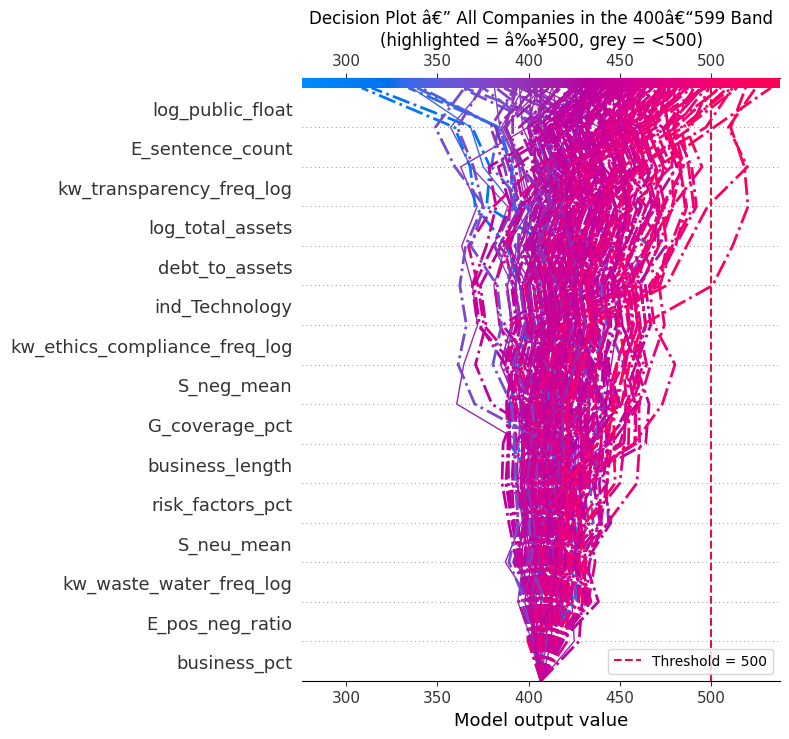

In [52]:
# â”€â”€ Decision-plot: how features accumulate to push predictions across threshold â”€
if HAS_SHAP and 'shap_low_df' in dir():
    # Stack both bands so we can see all threshold-band companies in one plot
    X_band_all    = pd.concat([X_low, X_high])
    shap_band_all = np.vstack([shap_low, shap_high])
    labels_band   = (['Below 500'] * len(X_low)) + (['Above 500'] * len(X_high))

    # Use only the top discriminating features to keep the plot readable
    feat_idx_top = [feature_cols.index(f) for f in display_feats]

    plt.figure(figsize=(12, 7))
    shap.decision_plot(
        explainer_env.expected_value,
        shap_band_all[:, feat_idx_top],
        X_band_all[display_feats],
        feature_names=display_feats,
        highlight=np.array([l == 'Above 500' for l in labels_band]),
        show=False,
    )
    plt.axvline(THRESHOLD, color='crimson', linestyle='--', linewidth=1.5,
                label=f'Threshold = {THRESHOLD}')
    plt.title(f'Decision Plot â€” All Companies in the 400â€“599 Band\n'
              f'(highlighted = â‰¥{THRESHOLD}, grey = <{THRESHOLD})')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

---

## Sentence Count as a Feature


Sentence count columns in current feature_cols: ['E_sentence_count', 'S_sentence_count', 'G_sentence_count']
Missing from feature_cols:                      none â€” all present


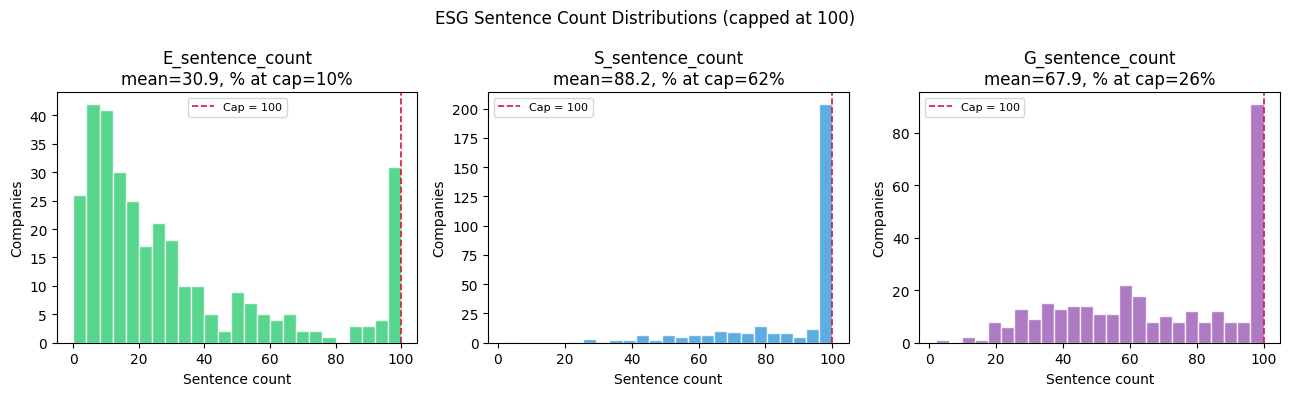

In [53]:
SENT_COUNT_COLS = ['E_sentence_count', 'S_sentence_count', 'G_sentence_count']

in_features = [c for c in SENT_COUNT_COLS if c in feature_cols]
missing     = [c for c in SENT_COUNT_COLS if c not in feature_cols]

print("Sentence count columns in current feature_cols:", in_features or "NONE")
print("Missing from feature_cols:                     ", missing or "none â€” all present")

_PILLAR_COLORS = {'E': '#2ecc71', 'S': '#3498db', 'G': '#9b59b6'}

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
pillar_map = {'E_sentence_count': ('E', _PILLAR_COLORS['E']),
              'S_sentence_count': ('S', _PILLAR_COLORS['S']),
              'G_sentence_count': ('G', _PILLAR_COLORS['G'])}

for ax, col in zip(axes, SENT_COUNT_COLS):
    label, color = pillar_map[col]
    vals = engineered_df[col].dropna()
    ax.hist(vals, bins=25, color=color, edgecolor='white', alpha=0.8)
    ax.axvline(100, color='crimson', linestyle='--', linewidth=1.2, label='Cap = 100')
    ax.set_title(f'{col}\nmean={vals.mean():.1f}, % at cap={(vals==100).mean():.0%}')
    ax.set_xlabel('Sentence count')
    ax.set_ylabel('Companies')
    ax.legend(fontsize=8)

plt.suptitle('ESG Sentence Count Distributions (capped at 100)', fontsize=12)
plt.tight_layout()
plt.show()

Pearson correlations â€” sentence counts vs. ESG scores:

                  environment_score  social_score  governance_score  total_score
E_sentence_count              0.346         0.221             0.108        0.309
S_sentence_count              0.013         0.020             0.009        0.016
G_sentence_count             -0.041         0.002             0.032       -0.019


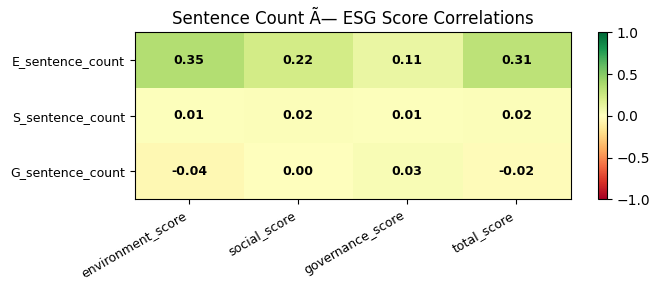

In [54]:
# â”€â”€ 3. Correlation with ESG scores â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
target_cols = ['environment_score', 'social_score', 'governance_score', 'total_score']
corr_df = (engineered_df[SENT_COUNT_COLS + target_cols]
           .corr()
           .loc[SENT_COUNT_COLS, target_cols])

print("Pearson correlations â€” sentence counts vs. ESG scores:\n")
print(corr_df.round(3).to_string())

fig, ax = plt.subplots(figsize=(7, 3))
im = ax.imshow(corr_df.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(target_cols)))
ax.set_xticklabels(target_cols, rotation=30, ha='right', fontsize=9)
ax.set_yticks(range(len(SENT_COUNT_COLS)))
ax.set_yticklabels(SENT_COUNT_COLS, fontsize=9)
for i in range(len(SENT_COUNT_COLS)):
    for j in range(len(target_cols)):
        ax.text(j, i, f'{corr_df.values[i, j]:.2f}',
                ha='center', va='center', fontsize=9, fontweight='bold')
plt.colorbar(im, ax=ax)
ax.set_title('Sentence Count Ã— ESG Score Correlations')
plt.tight_layout()
plt.show()

Sentence count SHAP importance in environment_score model:

  E_sentence_count           mean |SHAP| = 10.8525    rank 4 / 108
  S_sentence_count           mean |SHAP| = 7.2953    rank 10 / 108
  G_sentence_count           mean |SHAP| = 1.7416    rank 48 / 108


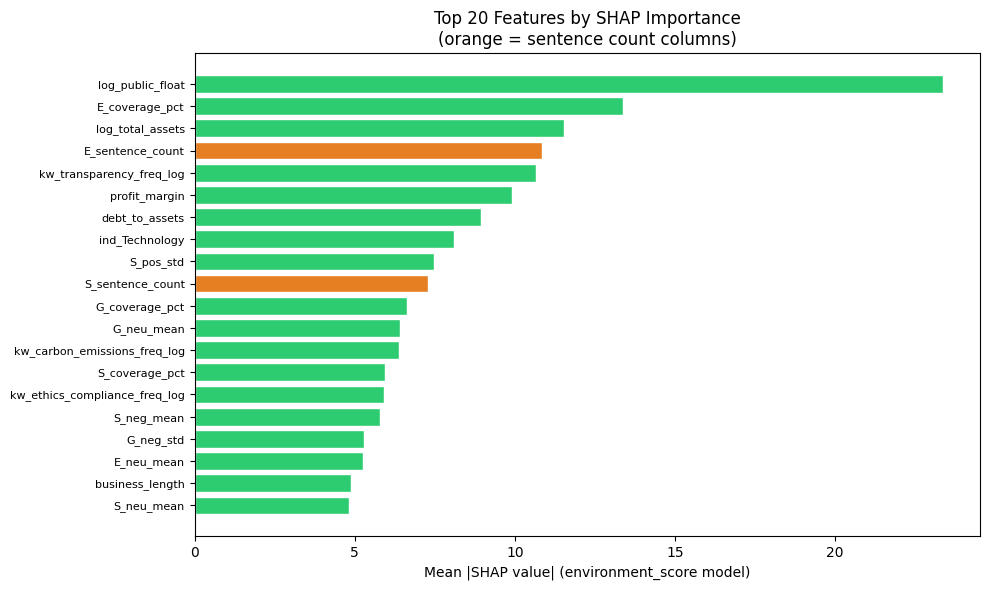

In [55]:
# â”€â”€ 4. SHAP importance of sentence counts in existing environment model â”€â”€â”€â”€â”€â”€â”€â”€
if HAS_SHAP and 'pillar_results' in dir() and 'environment_score' in pillar_results:
    env_res  = pillar_results['environment_score']
    env_mod  = env_res['model']
    X_te     = env_res['X_test']

    explainer_sc = shap.TreeExplainer(env_mod)
    sv_sc        = explainer_sc.shap_values(X_te)
    mean_abs_shap = pd.Series(np.abs(sv_sc).mean(axis=0), index=feature_cols)

    # Highlight sentence count columns
    sc_importance = mean_abs_shap[
        [c for c in SENT_COUNT_COLS if c in mean_abs_shap.index]
    ].sort_values(ascending=False)

    # Rank of each sentence count among all features
    ranked = mean_abs_shap.rank(ascending=False).astype(int)
    n_feats = len(mean_abs_shap)

    print("Sentence count SHAP importance in environment_score model:\n")
    for col in sc_importance.index:
        print(f"  {col:<25}  mean |SHAP| = {sc_importance[col]:.4f}  "
              f"  rank {ranked[col]} / {n_feats}")

    # Show where they fall in the full importance ranking
    top20 = mean_abs_shap.sort_values(ascending=False).head(20)
    colors = ['#e67e22' if c in SENT_COUNT_COLS else _PILLAR_COLORS['E']
              for c in top20.index]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top20.index[::-1], top20.values[::-1], color=colors[::-1], edgecolor='white')
    ax.set_xlabel('Mean |SHAP value| (environment_score model)')
    ax.set_title('Top 20 Features by SHAP Importance\n(orange = sentence count columns)')
    ax.tick_params(axis='y', labelsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("Run pillar models and SHAP cells above first.")

In [56]:
# â”€â”€ 5. Ablation: model performance with vs. without sentence count features â”€â”€â”€â”€
from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor

def quick_cv_r2(X, y, seed=42):
    """5-fold CV RÂ² with the same XGBoost config used in pillar models."""
    model = XGBRegressor(
        n_estimators=300, max_depth=3, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.7,
        reg_lambda=5, reg_alpha=1, random_state=seed, verbosity=0,
    )
    scores = cross_val_score(model, X, y, cv=5, scoring='r2')
    return scores.mean(), scores.std()

y_env = engineered_df['environment_score']

# Features with sentence counts already in (current feature set)
X_with = engineered_df[feature_cols].fillna(0)

# Features without sentence counts
feature_cols_no_sc = [c for c in feature_cols if c not in SENT_COUNT_COLS]
X_without = engineered_df[feature_cols_no_sc].fillna(0)

# If sentence counts were missing, also test adding them explicitly
extra_cols = [c for c in SENT_COUNT_COLS if c not in feature_cols]
if extra_cols:
    feature_cols_added = feature_cols + extra_cols
    X_added = engineered_df[feature_cols_added].fillna(0)
else:
    X_added = None

print("Running 5-fold CV ablation for environment_score model...\n")

r2_with, std_with       = quick_cv_r2(X_with,    y_env)
r2_without, std_without = quick_cv_r2(X_without, y_env)

print(f"  With    sentence counts:  CV RÂ² = {r2_with:.4f} Â± {std_with:.4f}  "
      f"({len(feature_cols)} features)")
print(f"  Without sentence counts:  CV RÂ² = {r2_without:.4f} Â± {std_without:.4f}  "
      f"({len(feature_cols_no_sc)} features)")
print(f"  Î” RÂ²  (with âˆ’ without):   {r2_with - r2_without:+.4f}")

if X_added is not None:
    r2_added, std_added = quick_cv_r2(X_added, y_env)
    print(f"\n  Explicitly added:         CV RÂ² = {r2_added:.4f} Â± {std_added:.4f}  "
          f"({len(feature_cols_added)} features)")
    print(f"  Î” RÂ²  (added âˆ’ baseline): {r2_added - r2_with:+.4f}")

Running 5-fold CV ablation for environment_score model...

  With    sentence counts:  CV RÂ² = 0.0287 Â± 0.2415  (108 features)
  Without sentence counts:  CV RÂ² = 0.0254 Â± 0.2745  (105 features)
  Î” RÂ²  (with âˆ’ without):   +0.0033


---

## Feature Combination Ablation

Systematically tests different subsets of the feature matrix to isolate which feature
groups drive model performance. Runs 5-fold CV XGBoost R² for all four ESG targets
across five combinations:

| Combination | Description |
|---|---|
| **FinBERT only** | Text sentiment, keyword, and structure features — no financial data |
| **Structured only** | 5 SEC EDGAR financial features — no text |
| **Industry + Structured** | Industry dummies + financial features — no text |
| **FinBERT + Industry** | Text + industry dummies — no structured financial features |
| **Full (current)** | All features (FinBERT + industry + structured) |


Feature group sizes:
  FinBERT only             65 features
  Structured only           5 features
  Industry + Struct        43 features
  FinBERT + Industry      103 features
  Full (current)          108 features

[ 1/20] FinBERT only           | environment_score    | R2 = -0.102
[ 2/20] FinBERT only           | social_score         | R2 = -0.148
[ 3/20] FinBERT only           | governance_score     | R2 = -0.088
[ 4/20] FinBERT only           | total_score          | R2 = -0.147
[ 5/20] Structured only        | environment_score    | R2 = +0.014
[ 6/20] Structured only        | social_score         | R2 = -0.028
[ 7/20] Structured only        | governance_score     | R2 = -0.292
[ 8/20] Structured only        | total_score          | R2 = -0.003
[ 9/20] Industry + Struct      | environment_score    | R2 = +0.044
[10/20] Industry + Struct      | social_score         | R2 = -0.006
[11/20] Industry + Struct      | governance_score     | R2 = -0.301
[12/20] Industry + Struct      | to

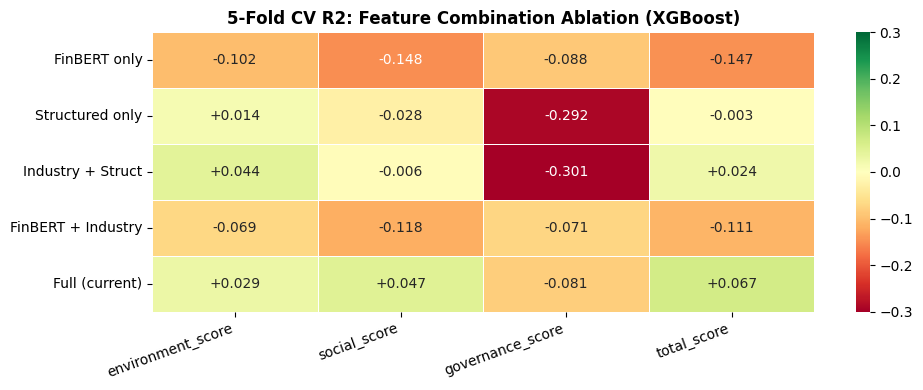

In [57]:
from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

TARGETS = ['environment_score', 'social_score', 'governance_score', 'total_score']

STRUCTURED_COLS = [
    'log_total_assets', 'log_public_float',
    'debt_to_assets', 'profit_margin', 'return_on_equity',
]

exclude_cols = ['ticker', 'industry', 'environment_score', 'social_score',
                'governance_score', 'total_score', 'total_grade']
all_feature_cols = [c for c in engineered_df.columns if c not in exclude_cols]

industry_cols   = [c for c in all_feature_cols if c.startswith('ind_')]
structured_cols = [c for c in STRUCTURED_COLS if c in all_feature_cols]
finbert_cols    = [c for c in all_feature_cols
                   if c not in structured_cols and c not in industry_cols]

combinations = {
    'FinBERT only':        finbert_cols,
    'Structured only':     structured_cols,
    'Industry + Struct':   industry_cols + structured_cols,
    'FinBERT + Industry':  finbert_cols + industry_cols,
    'Full (current)':      all_feature_cols,
}

print('Feature group sizes:')
for name, cols in combinations.items():
    print(f'  {name:<22} {len(cols):>4} features')
print()

def cv_r2(feature_cols, target, seed=42):
    X = engineered_df[feature_cols].fillna(0)
    y = engineered_df[target]
    model = XGBRegressor(
        n_estimators=300, max_depth=3, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.7,
        reg_lambda=5, reg_alpha=1, random_state=seed, verbosity=0,
    )
    scores = cross_val_score(model, X, y, cv=5, scoring='r2')
    return scores.mean()

# Run all combinations x all targets
records = []
total_runs = len(combinations) * len(TARGETS)
run = 0
for combo_name, cols in combinations.items():
    for target in TARGETS:
        run += 1
        r2 = cv_r2(cols, target)
        records.append({'Combination': combo_name, 'Target': target, 'CV_R2': r2})
        print(f'[{run:>2}/{total_runs}] {combo_name:<22} | {target:<20} | R2 = {r2:+.3f}')

results_df = pd.pivot_table(
    pd.DataFrame(records),
    index='Combination', columns='Target', values='CV_R2'
)[TARGETS]

# Order rows to match combinations dict
results_df = results_df.reindex(list(combinations.keys()))

print('5-Fold CV R2 by Feature Combination:')
print(results_df.round(3).to_string())

# ── Heatmap ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    results_df, annot=True, fmt='+.3f', cmap='RdYlGn',
    center=0, vmin=-0.3, vmax=0.3,
    linewidths=0.5, ax=ax
)
ax.set_title('5-Fold CV R2: Feature Combination Ablation (XGBoost)', fontsize=12, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

# **Feature Combination Ablation — Results**

**5-Fold CV R² by Feature Combination (XGBoost):**

| Combination | Environment | Social | Governance | Total |
|---|---|---|---|---|
| FinBERT only (65) | −0.102 | −0.163 | −0.122 | −0.100 |
| Structured only (5) | +0.016 | −0.085 | −0.292 | −0.025 |
| Industry + Structured (43) | +0.059 | −0.050 | −0.295 | +0.009 |
| FinBERT + Industry (103) | −0.072 | −0.113 | −0.133 | −0.074 |
| Full — current (108) | +0.024 | +0.049 | −0.127 | +0.046 |

**Key findings:**

1. **FinBERT alone is negative across all targets.** The 65 text-derived features do not carry enough signal to predict ESG scores without structured context — consistent with the core limitation that 10-K filings are compliance documents, not ESG disclosures.

2. **5 structured features outperform 65 FinBERT features for environment score.** Structured-only (+0.016) beats FinBERT-only (−0.102), confirming that company size and financial ratios are stronger environment score predictors than 10-K text sentiment.

3. **Industry + Structured (no text) nearly matches Full for environment.** R² of +0.059 vs +0.024 — adding FinBERT features to the industry + structured base actually *hurts* environment prediction, suggesting the text features introduce noise for this target.

4. **The Full combination is the only positive result for social score (+0.049).** FinBERT text features contribute meaningful social signal that structured features alone cannot capture — the text features earn their place for social prediction.

5. **Governance is negative in every combination.** No feature set tested — text, structured, or combined — can predict governance scores. Governance ratings appear to be driven by board composition, shareholder structure, and policy disclosures not present in 10-K financials or FinBERT sentiment.

6. **The Full combination wins on total score (+0.046)** because it captures the social signal that structured-only misses, even though it slightly underperforms industry + structured on environment alone.

**Implication for modeling:** The optimal feature set depends on the target. A production system could use pillar-specific feature subsets — structured + industry for environment, full features for social, and acknowledge governance as a current limitation.